In [1]:
# v6 - rejig the figures.. 

In [2]:
## v3 edits : keep everything fully spatial till last moment, so i can plot maps

import numpy as np
import xarray as xr
import os
import glob
import matplotlib.pyplot as plt
import pandas as pd
import json
import cftime
from cftime import DatetimeNoLeap
from scipy import stats
from scipy.interpolate import interp1d
import dask
from tqdm import tqdm
#from mpl_axes_aligner import align
from xmip.preprocessing import rename_cmip6
%matplotlib inline
#import xesmf as xe
import matplotlib
from utils import QACC_utils
#from utils.config import model, min_lat, max_lat, min_year_late_cent, max_year_late_cent
##### SETTINGS
model = 'UKESM1-0-LL'
regions = ['Arctic', 'Tropics']
lat_band_dict = {'Arctic':[66, 90],
                 'Tropics':[-23, 23]}
scenarios = ['ssp245', 'ARISE', 'ssp245_baseline']
experiment_dict = {'ssp245':'ssp245', 
                   'ARISE':'ARISE',
                   'ssp245_baseline':'ssp245'}
time_slice_dict = {'ssp245':['2050', '2069'], 
                   'ARISE':['2050', '2069'],
                   'ssp245_baseline':['2015', '2033']} # we take a 19 year baseline to avoid having to read in the historical runs to get the year 2014

from utils.Utils import weighted_annual_resample, get_ds_from_ceda, spatial_mean

In [3]:
matplotlib.rcParams.update({'font.size': 15})

In [4]:
## colorscheme for all contributions:
color_scheme = {
     'F': '#e57373',       # Muted red
    'AHT': '#64b5f6',     # Sky blue
    'OHU': '#81c784',     # Mint green
    'Planck': '#ba68c8',  # Soft purple
    'Planck_dash':'#ba68c8',  # feedback plots call planck_dash but this needs to be the same plotting colour as 'planck' later
    'Alb': '#ffb74d',     # Burnt orange
    'LR': '#fff176',      # Pastel yellow
    'WV': '#a1887f',      # Dusty brown
    'Cloud': '#f06292',    # Pale pink
    'T_strat':'green',
    'q_strat':'hotpink',
    'Residual':'dimgrey'
}

process_labels = {'F':'F_aer',
                  'AHT':'AHT',
                  'OHU':'OHU',
                  'Planck':'Planck',
                  'Planck_dash':'Planck', # feedback plots call planck_dash but this needs to be the same plotting colour as 'planck' later
                  'Alb':'Albedo',
                  'LR':'Lapse Rate',
                  'WV':'Water vapour',
                  'T_strat':'T_strat',
                  'q_strat':'q_strat',
                  'Cloud':'Cloud'}

In [5]:
dict_list = []
for scen in scenarios:
    ds_list = []
    for region in regions:
        ds =  xr.open_dataset('intermediate_outputs/fin/{s}_{l}_{m}.nc'.format(
            s=scen, l=str(lat_band_dict[region][0]), m=model))
        ds_list.append(ds)
    scen_dict = dict(zip(regions, ds_list))
    dict_list.append(scen_dict)
spatial_means_dict = dict(zip(scenarios, dict_list))

In [6]:
print(spatial_means_dict['ARISE']['Arctic'].IRF_aer.mean())

<xarray.DataArray 'IRF_aer' ()> Size: 8B
array(-3.61503837)
Coordinates:
    height   float64 8B ...


In [7]:
spatial_means_dict['ssp245_baseline']['Arctic']

<xarray.Dataset> Size: 9kB
Dimensions:                 (month: 12, bnds: 2, plev: 19)
Coordinates:
    height                  float64 8B ...
  * month                   (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * plev                    (plev) float64 152B 1e+05 9.25e+04 ... 500.0 100.0
Dimensions without coordinates: bnds
Data variables: (12/33)
    lat_bounds              (month, bnds) float64 192B ...
    lon_bounds              (month, bnds) float64 192B ...
    tas                     (month) float64 96B ...
    number_ens_mems_meaned  (month) float64 96B ...
    rsds                    (month) float64 96B ...
    rsus                    (month) float64 96B ...
    ...                      ...
    AHTmoist                (month) float64 96B ...
    AHTdry                  (month) float64 96B ...
    IRF_aer                 (month) float64 96B ...
    IRF_aer_cs              (month) float64 96B ...
    albedo                  (month) float64 96B ...
    CRE                     (month) float64 96B ...

Text(0.5, 0.98, 'AHT')

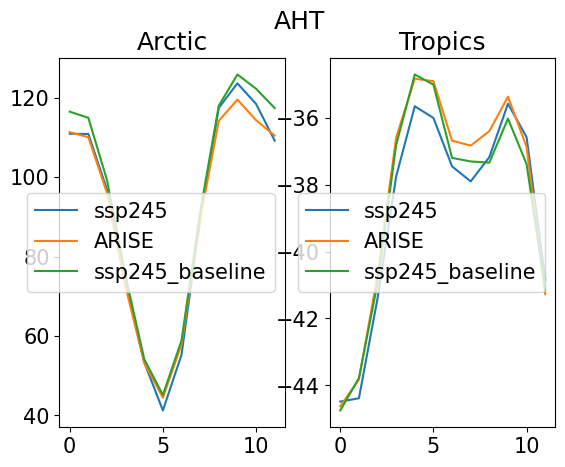

In [8]:
fig, axs = plt.subplots(1, 2)
i=0
for region in regions:
    ax = axs[i]
    for scen in scenarios:
        ax.plot(spatial_means_dict[scen][region].AHT.values, label=scen)
    ax.legend()
    ax.set_title(region)
    i=i+1
plt.suptitle('AHT')

Text(0.5, 0.98, 'OHU')

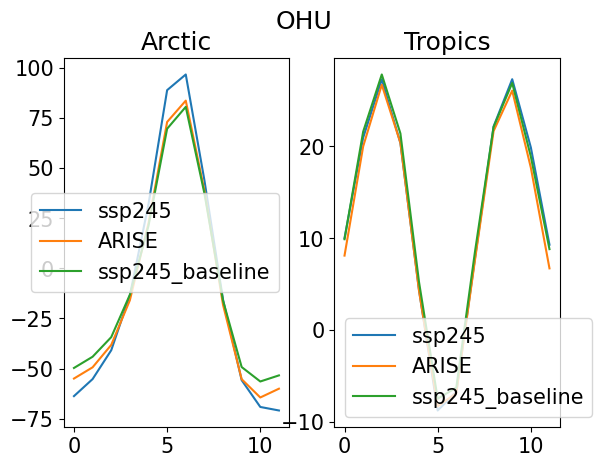

In [9]:
fig, axs = plt.subplots(1, 2)
i=0
for region in regions:
    ax = axs[i]
    for scen in scenarios:
        ax.plot(spatial_means_dict[scen][region].OHU.values, label=scen)
    ax.legend()
    ax.set_title(region)
    i=i+1
plt.suptitle('OHU')

In [10]:
os.listdir('intermediate_outputs/feedbacks/')

['baseline_ssp245_feedbacks.nc',
 'ssp245_ARISE_feedbacks.nc',
 'baseline_ARISE_feedbacks.nc']

In [11]:
# read in feedbacks (W/m2 - so R units)
Rs_sai = xr.open_dataset('intermediate_outputs/feedbacks/ssp245_ARISE_feedbacks.nc')
Rs_ssp = xr.open_dataset('intermediate_outputs/feedbacks/baseline_ssp245_feedbacks.nc')
Rs_sai_vs_baseline = xr.open_dataset('intermediate_outputs/feedbacks/baseline_ARISE_feedbacks.nc')


def add_extra_Rs(Rs):
    Planck_global_mean_lambda = QACC_utils.calc_spatial_mean(Rs.Planck, 'lon', 'lat')/QACC_utils.calc_spatial_mean(Rs.delta_TS, 'lon', 'lat') # W/m2/K
    Planck_global_mean_cs_lambda = QACC_utils.calc_spatial_mean(Rs.Planck_cs, 'lon', 'lat')/QACC_utils.calc_spatial_mean(Rs.delta_TS, 'lon', 'lat') # W/m2/K

    Planck_global_mean = QACC_utils.calc_spatial_mean(Rs.Planck, 'lon', 'lat') # W/m2
    Planck_global_mean_cs = QACC_utils.calc_spatial_mean(Rs.Planck_cs, 'lon', 'lat') # W/m2
    
    # this one is the real calc
    Rs['Planck_dash'] = (Rs['Planck']/Rs['delta_TS'] - Planck_global_mean_lambda)*Rs['delta_TS'] # keep these in W/m2 units, but global mean planck in W/m2/K units
    Rs['Planck_dash_cs'] = (Rs['Planck_cs']/Rs['delta_TS'] - Planck_global_mean_cs_lambda)*Rs['delta_TS'] # keep these in W/m2 units, but global mean planck in W/m2/K units

    # try simpler (but wrong, i think) planck calc to check it doesn fix things - it doesnt
    #Rs['Planck_dash'] = -(Rs['Planck'] - Planck_global_mean) 
    #Rs['Planck_dash_cs'] = -(Rs['Planck_cs'] - Planck_global_mean_cs) 
    
    Rs_arctic_mean = QACC_utils.calc_spatial_mean(Rs.sel(lat=slice(lat_band_dict['Arctic'][0], lat_band_dict['Arctic'][1])), 'lon', 'lat')
    Rs_tropics_mean = QACC_utils.calc_spatial_mean(Rs.sel(lat=slice(lat_band_dict['Tropics'][0], lat_band_dict['Tropics'][1])), 'lon', 'lat')

    # also save planck mean for later
    Rs_arctic_mean['Planck_global_mean_lambda'] = Planck_global_mean_lambda
    Rs_tropics_mean['Planck_global_mean_lambda'] = Planck_global_mean_lambda
    return Rs, Rs_arctic_mean, Rs_tropics_mean

Rs_sai, Rs_sai_arctic, Rs_sai_tropics = add_extra_Rs(Rs_sai)
Rs_ssp, Rs_ssp_arctic, Rs_ssp_tropics = add_extra_Rs(Rs_ssp)
Rs_sai_vs_baseline, Rs_sai_vs_baseline_arctic, Rs_sai_vs_baseline_tropics = add_extra_Rs(Rs_sai_vs_baseline)



Rs_dict = {'sai':{'Arctic':Rs_sai_arctic, 'Tropics':Rs_sai_tropics, 'Spatial':Rs_sai},
           'ssp':{'Arctic':Rs_ssp_arctic, 'Tropics':Rs_ssp_tropics, 'Spatial':Rs_ssp},
           'sai_vs_baseline':{'Arctic':Rs_sai_vs_baseline_arctic, 'Tropics':Rs_sai_vs_baseline_tropics, 'Spatial':Rs_sai_vs_baseline}}

### NB - the code is set up to allow this third scenario to run, i.e. to compare SAI against the target state (the baseline)
### BUT - the method doesn't work here, some thought is needed on how to apply it to the scenario without a strong signal in 
### delta T and an overall forcing. The breakdown is clear from the two arrays printed in below - planck should be negative 
### and cosistent, but isn't for the sai_vs_baseline case, so for now I will leave this case out. 
print(Rs_dict['sai']['Tropics']['Planck_global_mean_lambda'].values)
print(Rs_dict['sai_vs_baseline']['Tropics']['Planck_global_mean_lambda'].values)

[-3.16203443 -3.20297703 -3.25134889 -3.30078648 -3.32634303 -3.36176194
 -3.38721186 -3.37955992 -3.35978414 -3.28394959 -3.19775559 -3.16214225]
[-1.66507918 -1.47141815 -1.64364402 -1.0587235   3.93355058  6.98138596
 -4.92809952 11.22492874  2.1090017  -1.01519754 -1.1549494  -1.02155346]


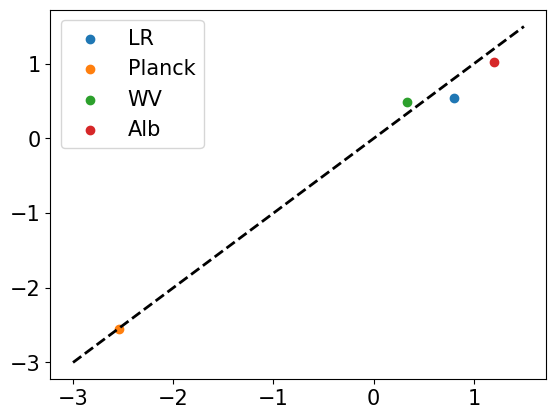

In [12]:
## to do: plot the feedback strength directly, i.e. R/deltaT

fig, ax = plt.subplots()

for f in ['LR', 'Planck', 'WV', 'Alb']:
    lambda_f_sai = Rs_dict['sai']['Arctic'].mean('time')[f].values/Rs_dict['sai']['Arctic'].mean('time')['delta_TS'].values
    lambda_f_ssp = Rs_dict['ssp']['Arctic'].mean('time')[f].values/Rs_dict['ssp']['Arctic'].mean('time')['delta_TS'].values
    ax.scatter(lambda_f_ssp, lambda_f_sai, label=f)
ax.legend()
line = [-3, 1.5]
ax.plot(line, line, c='black', linewidth=2, linestyle='--')

In [13]:
ds_delta_sm_sai_arctic = (spatial_means_dict['ARISE']['Arctic'] - spatial_means_dict['ssp245']['Arctic']).rename({'month':'time'})
ds_delta_sm_ssp_arctic = (spatial_means_dict['ssp245']['Arctic'] - spatial_means_dict['ssp245_baseline']['Arctic']).rename({'month':'time'})
ds_delta_sm_sai_vs_baseline_arctic = (spatial_means_dict['ARISE']['Arctic'] - spatial_means_dict['ssp245_baseline']['Arctic']).rename({'month':'time'})

ds_delta_sm_sai_tropics = (spatial_means_dict['ARISE']['Tropics'] - spatial_means_dict['ssp245']['Tropics']).rename({'month':'time'})
ds_delta_sm_ssp_tropics = (spatial_means_dict['ssp245']['Tropics'] - spatial_means_dict['ssp245_baseline']['Tropics']).rename({'month':'time'})
ds_delta_sm_sai_vs_baseline_tropics = (spatial_means_dict['ARISE']['Tropics'] - spatial_means_dict['ssp245_baseline']['Tropics']).rename({'month':'time'})

print(ds_delta_sm_sai_arctic.tas.mean('time').item())
print(ds_delta_sm_ssp_arctic.tas.mean('time').item())
print(ds_delta_sm_sai_vs_baseline_arctic.tas.mean('time').item())

print(ds_delta_sm_sai_tropics.tas.mean('time').item())
print(ds_delta_sm_ssp_tropics.tas.mean('time').item())
print(ds_delta_sm_sai_vs_baseline_tropics.tas.mean('time').item())

deltas_dict = {'sai':{'Arctic':ds_delta_sm_sai_arctic, 'Tropics':ds_delta_sm_sai_tropics},
               'ssp':{'Arctic':ds_delta_sm_ssp_arctic, 'Tropics':ds_delta_sm_ssp_tropics},
               'sai_vs_baseline':{'Arctic':ds_delta_sm_sai_vs_baseline_arctic, 'Tropics':ds_delta_sm_sai_vs_baseline_tropics}}

-3.7508027092677856
5.231382299270993
1.480579590003207
-1.479591238254874
1.419335654085027
-0.06025558416984703


In [14]:
all_feedbacks = ['Planck', 'Alb', 'LR', 'WV', 'T_strat', 'q_strat']

dict_list = []
for scen in ['sai', 'ssp', 'sai_vs_baseline']:
    ds_list = []
    for region in regions:
        Rs = Rs_dict[scen][region]
        delta_ds = deltas_dict[scen][region]
        feedback_masking = sum([(Rs[str(feedback+'_cs')] - Rs[feedback]) for feedback in all_feedbacks])
        IRF_masking = delta_ds['IRF_aer_cs'] - delta_ds['IRF_aer']
        cloud_R = delta_ds['CRE'] + feedback_masking + IRF_masking  
        ds_list.append(cloud_R)
    regions_cloudR_dict = dict(zip(regions, ds_list))
    dict_list.append(regions_cloudR_dict)
cloudR_dict = dict(zip(['sai', 'ssp', 'sai_vs_baseline'], dict_list))

In [65]:
delta_ds['IRF_aer'].sel(time=slice(6,8), drop=True).mean()

<xarray.DataArray 'IRF_aer' ()> Size: 8B
array(-5.09984664)
Coordinates:
    height   float64 8B 1.5

In [15]:
Rs_dict['sai']

{'Arctic': <xarray.Dataset> Size: 2kB
 Dimensions:                    (time: 12)
 Coordinates:
   * time                       (time) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
     height                     float64 8B ...
     units                      <U5 20B ...
 Data variables: (12/16)
     LR                         (time) float64 96B -4.663 -3.369 ... -6.272
     Planck                     (time) float64 96B 12.23 9.63 ... 16.59 16.21
     WV                         (time) float64 96B -0.2853 -0.3899 ... -0.3404
     Alb                        (time) float64 96B -0.01005 ... -9.017e-05
     LR_cs                      (time) float64 96B -3.607 -2.587 ... -4.958
     Planck_cs                  (time) float64 96B 12.86 10.16 ... 17.7 17.12
     ...                         ...
     q_strat                    (time) float64 96B -0.02312 -0.04868 ... -0.03911
     q_strat_cs                 (time) float64 96B -0.02474 -0.05062 ... -0.04083
     delta_TS                   (time) float64 96B

In [16]:
# added this to show the arctic mean OHU

## Arctic-mean delta OHU (W/m2)
## sign: positive = into the ocean (see comment in get_delta_T_contribs_dict)

print('Arctic (66-90N) mean delta OHU:\n')
for scen, label in {'sai_vs_baseline': 'ARISE - baseline   ',
                    'sai':             'ARISE - SSP2-4.5   ',
                    'ssp':             'SSP2-4.5 - baseline'}.items():
    dOHU = deltas_dict[scen]['Arctic'].OHU
    print(f'  {label}: {dOHU.mean("time").item():+.2f} W/m2  '
          f'(monthly range {dOHU.min().item():+.2f} to {dOHU.max().item():+.2f})')

Arctic (66-90N) mean delta OHU:

  ARISE - baseline   : -2.56 W/m2  (monthly range -7.98 to +3.39)
  ARISE - SSP2-4.5   : -1.26 W/m2  (monthly range -15.88 to +10.87)
  SSP2-4.5 - baseline: -1.30 W/m2  (monthly range -17.51 to +19.27)


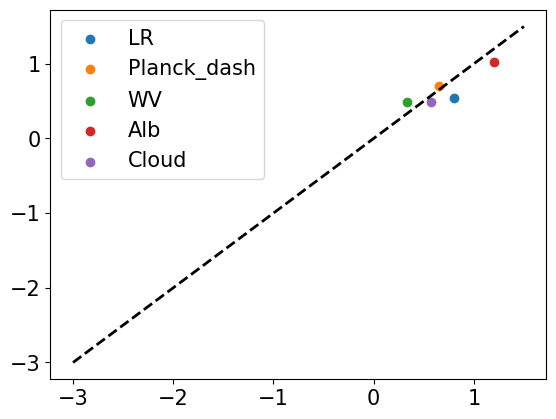

In [17]:
## to do: plot the feedback strength directly, i.e. R/deltaT

fig, ax = plt.subplots()

for f in ['LR', 'Planck_dash', 'WV', 'Alb']:
    lambda_f_sai = Rs_dict['sai']['Arctic'].mean('time')[f].values/Rs_dict['sai']['Arctic'].mean('time')['delta_TS'].values
    lambda_f_ssp = Rs_dict['ssp']['Arctic'].mean('time')[f].values/Rs_dict['ssp']['Arctic'].mean('time')['delta_TS'].values
    ax.scatter(lambda_f_ssp, lambda_f_sai, label=f)

lambda_cloud_sai = cloudR_dict['sai']['Arctic'].mean('time').values/Rs_dict['sai']['Arctic'].mean('time')['delta_TS'].values
lambda_cloud_ssp = cloudR_dict['ssp']['Arctic'].mean('time').values/Rs_dict['ssp']['Arctic'].mean('time')['delta_TS'].values

ax.scatter(lambda_cloud_ssp, lambda_cloud_sai, label='Cloud')

    
ax.legend()
line = [-3, 1.5]
ax.plot(line, line, c='black', linewidth=2, linestyle='--')

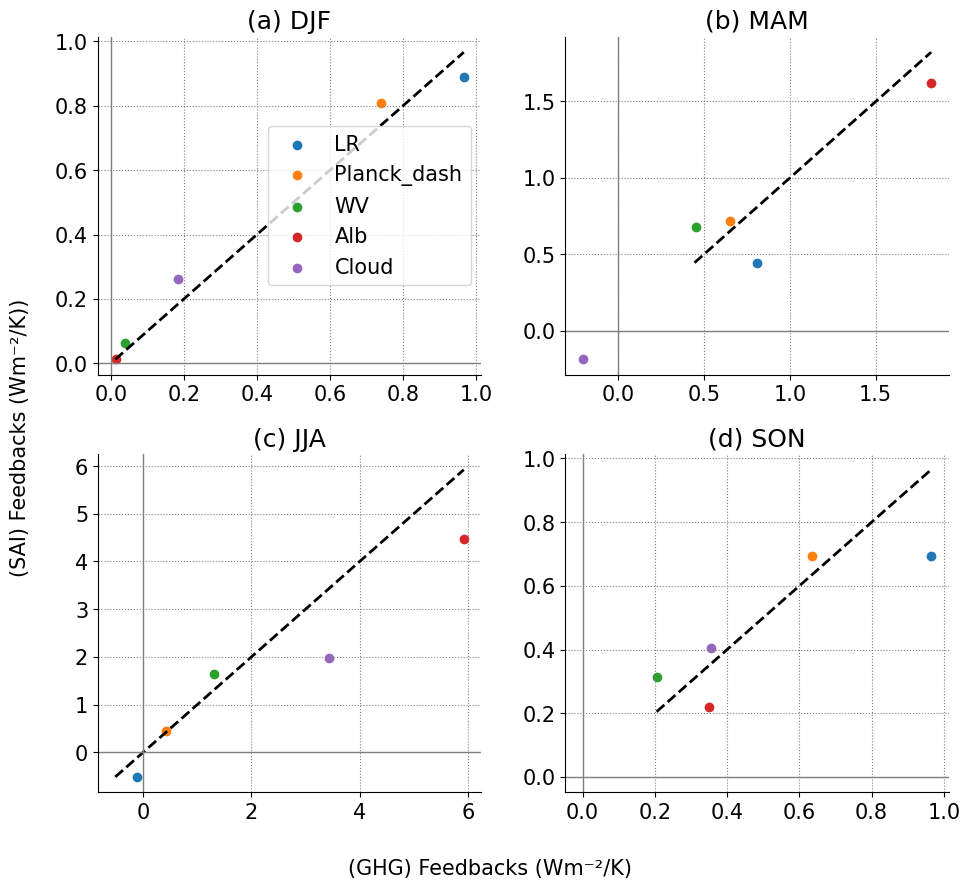

In [18]:
## add a seasonal version of the arctic warming vs cooling plot: 
## combine into one:

fig, axs = plt.subplots(2, 2, figsize = (10, 9), sharey=False, sharex=False)

titles = ['(a) DJF', '(b) MAM', 
          '(c) JJA', '(d) SON']
monthss = [[0,1,11], [2, 3, 4], [5, 6, 7], [8, 9, 10]]
region = 'Arctic'

for l in range(4):
    ax = axs.flatten()[l]
    months = monthss[l]

    fs=[]
    for f in ['LR', 'Planck_dash', 'WV', 'Alb']:
        lambda_f_sai = Rs_dict['sai']['Arctic'].isel(time=months).mean('time')[f].values/Rs_dict['sai']['Arctic'].isel(time=months).mean('time')['delta_TS'].values
        lambda_f_ssp = Rs_dict['ssp']['Arctic'].isel(time=months).mean('time')[f].values/Rs_dict['ssp']['Arctic'].isel(time=months).mean('time')['delta_TS'].values
        fs.append(lambda_f_sai)
        fs.append(lambda_f_ssp)
        ax.scatter(lambda_f_ssp, lambda_f_sai, label=f)

    lambda_cloud_sai = cloudR_dict['sai']['Arctic'].isel(time=months).mean('time').values/Rs_dict['sai']['Arctic'].isel(time=months).mean('time')['delta_TS'].values
    lambda_cloud_ssp = cloudR_dict['ssp']['Arctic'].isel(time=months).mean('time').values/Rs_dict['ssp']['Arctic'].isel(time=months).mean('time')['delta_TS'].values
    
    ax.scatter(lambda_cloud_ssp, lambda_cloud_sai, label='Cloud')
    
    line = [np.min(fs), np.max(fs)]
    ax.plot(line, line, c='black', linewidth=2, linestyle='--')
    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_title('')
    ax.grid(ls='dotted', c='gray')
    ax.axhline(0, c='gray', linewidth=1)
    ax.axvline(0, c='gray', linewidth=1)
       
    ax.set_title(titles[l])
    l=l+1
axs.flatten()[0].legend()

fig.supxlabel('(GHG) Feedbacks (Wm\u207B\u00B2/K)'.format(r=region), fontsize='medium')
fig.supylabel('(SAI) Feedbacks (Wm\u207B\u00B2/K))'.format(r=region), fontsize='medium')
plt.tight_layout()   
plt.savefig('figures/Feedbacks_seasonal_SAI_vs_GHGs.jpg'.format(r=region), dpi=300, bbox_inches='tight')

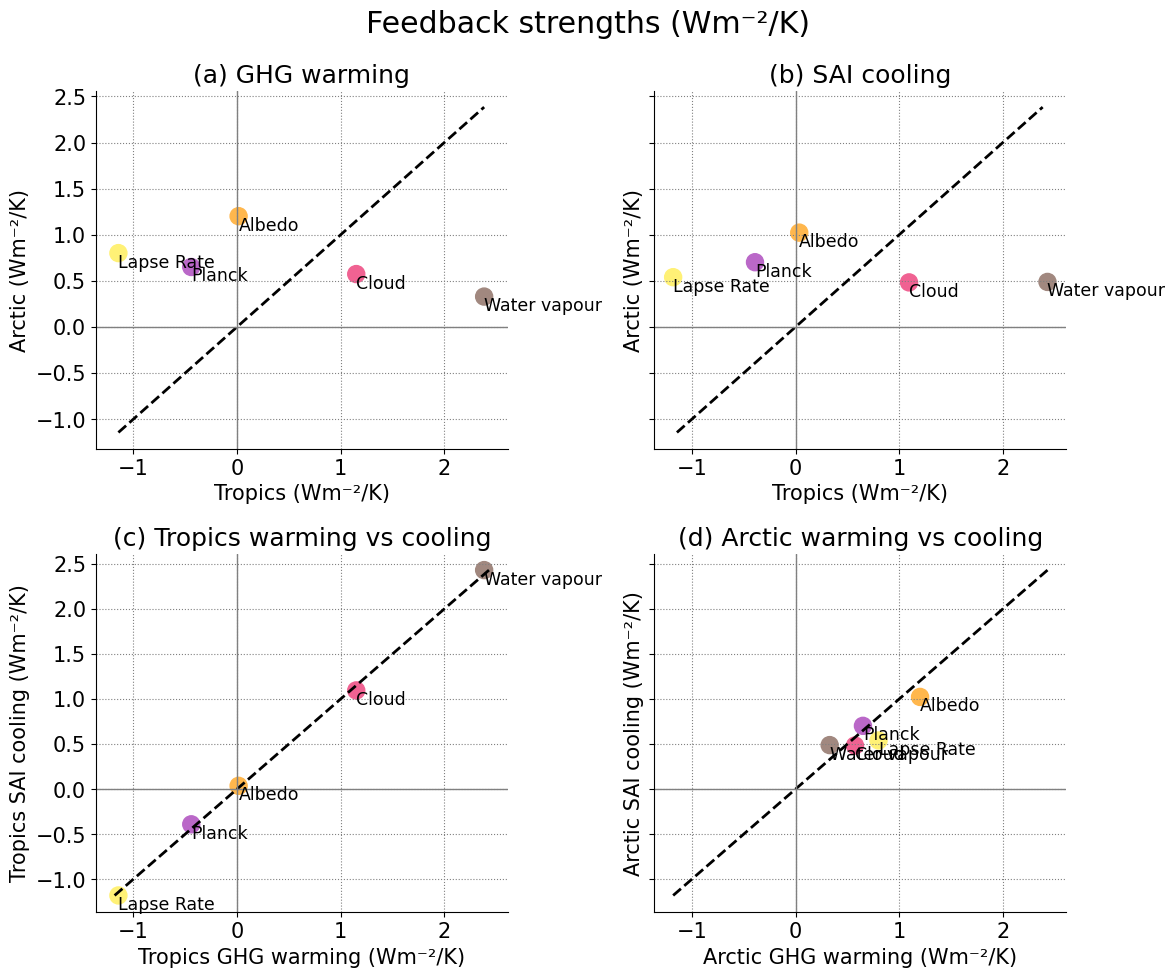

In [19]:
## also combine all the scatters into one: 

## plot the arctic vs tropical warming contributions under ssp and sai


### now plot for both regions:

fig, axs = plt.subplots(2, 2, figsize = (12, 10),
                       sharey='row', sharex='row')

l=0
titles=['(a) GHG warming', '(b) SAI cooling']

for scen in ['ssp', 'sai']:
    ax = axs[0, l]

    fs, fs_A, fs_T, labs = [], [], [], []
    for f in ['LR', 'Planck_dash', 'WV', 'Alb']:
        lambda_f_Arctic = Rs_dict[scen]['Arctic'].mean('time')[f].values/Rs_dict[scen]['Arctic'].mean('time')['delta_TS'].values
        lambda_f_Tropics = Rs_dict[scen]['Tropics'].mean('time')[f].values/Rs_dict[scen]['Tropics'].mean('time')['delta_TS'].values
        fs.append(lambda_f_Arctic)
        fs_A.append(lambda_f_Arctic)
        fs.append(lambda_f_Tropics)
        fs_T.append(lambda_f_Tropics)
        labs.append(f)
        #ax.scatter(lambda_f_Tropics, lambda_f_Arctic, label=f, zorder=1000)

    lambda_cloud_Arctic = cloudR_dict[scen]['Arctic'].mean('time').values/Rs_dict[scen]['Arctic'].mean('time')['delta_TS'].values
    lambda_cloud_Tropics = cloudR_dict[scen]['Tropics'].mean('time').values/Rs_dict[scen]['Tropics'].mean('time')['delta_TS'].values

    labs.append('Cloud')
    fs_A.append(lambda_cloud_Arctic)
    fs_T.append(lambda_cloud_Tropics)
    #ax.scatter(lambda_cloud_Arctic, lambda_cloud_Tropics, label='Cloud', zorder=1000)

    ax.scatter(fs_T, fs_A, s=150, c=[color_scheme[x] for x in labs])
    for i, txt in enumerate(labs):
        ax.annotate(process_labels[txt], (fs_T[i], fs_A[i]), va='top', ha='left', fontsize='small')
            
    if l == 0:
        line = [np.min(fs), np.max(fs)]
    ax.plot(line, line, c='black', linewidth=2, linestyle='--')
    
    ax.grid(ls='dotted', c='gray')
    ax.axhline(0, c='gray', linewidth=1)
    ax.axvline(0, c='gray', linewidth=1)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_title(titles[l])
    ax.set_xlabel('Tropics (Wm\u207B\u00B2/K)', fontsize='medium')
    ax.set_ylabel('Arctic (Wm\u207B\u00B2/K)', fontsize='medium')
    l=l+1



l=0
titles = ['(c) Tropics warming vs cooling', '(d) Arctic warming vs cooling']
for region in ['Tropics', 'Arctic']:
    ax = axs[1, l]
 

    fs, fs_A, fs_T, labs = [], [], [], []
    for f in ['LR', 'Planck_dash', 'WV', 'Alb']:
        lambda_f_sai = Rs_dict['sai'][region].mean('time')[f].values/Rs_dict['sai'][region].mean('time')['delta_TS'].values
        lambda_f_ssp = Rs_dict['ssp'][region].mean('time')[f].values/Rs_dict['ssp'][region].mean('time')['delta_TS'].values
        fs.append(lambda_f_sai)
        fs.append(lambda_f_ssp)
        fs.append(lambda_f_sai)
        fs_A.append(lambda_f_sai)
        fs.append(lambda_f_ssp)
        fs_T.append(lambda_f_ssp)
        labs.append(f)

    lambda_cloud_sai = cloudR_dict['sai'][region].mean('time').values/Rs_dict['sai'][region].mean('time')['delta_TS'].values
    lambda_cloud_ssp = cloudR_dict['ssp'][region].mean('time').values/Rs_dict['ssp'][region].mean('time')['delta_TS'].values
    labs.append('Cloud')
    fs_A.append(lambda_cloud_sai)
    fs_T.append(lambda_cloud_ssp)

    ax.scatter(fs_T, fs_A, s=150, c=[color_scheme[x] for x in labs])
    for i, txt in enumerate(labs):
        ax.annotate(process_labels[txt], (fs_T[i], fs_A[i]), va='top', ha='left', fontsize='small')
        
    if l == 0:
        line = [np.min(fs), np.max(fs)]
    ax.plot(line, line, c='black', linewidth=2, linestyle='--')
    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    ax.grid(ls='dotted', c='gray')
    ax.axhline(0, c='gray', linewidth=1)
    ax.axvline(0, c='gray', linewidth=1)
       
    ax.set_ylabel('{r} SAI cooling (Wm\u207B\u00B2/K)'.format(r=region), fontsize='medium')
    ax.set_xlabel('{r} GHG warming (Wm\u207B\u00B2/K)'.format(r=region), fontsize='medium')
    ax.set_title(titles[l])
    l=l+1

#axs[0, 0].legend()
plt.suptitle('Feedback strengths (Wm\u207B\u00B2/K)', fontsize='x-large')

plt.tight_layout()
plt.savefig('figures/all_warming_vs_cooling_feedback_stengths.jpg', dpi=300, bbox_inches='tight')

In [20]:
region = 'Arctic'
for f in ['LR', 'Planck_dash', 'WV', 'Alb']:
    lambda_f_sai = Rs_dict['sai'][region].mean('time')[f].values/Rs_dict['sai'][region].mean('time')['delta_TS'].values
    lambda_f_ssp = Rs_dict['ssp'][region].mean('time')[f].values/Rs_dict['ssp'][region].mean('time')['delta_TS'].values
    print(f)
    print(lambda_f_sai, lambda_f_ssp)
    print((lambda_f_sai-lambda_f_ssp)/lambda_f_ssp)

lambda_cloud_sai = cloudR_dict['sai'][region].mean('time').values/Rs_dict['sai'][region].mean('time')['delta_TS'].values
lambda_cloud_ssp = cloudR_dict['ssp'][region].mean('time').values/Rs_dict['ssp'][region].mean('time')['delta_TS'].values
print('cloud')
print(lambda_cloud_sai, lambda_cloud_ssp)
print((lambda_cloud_sai-lambda_cloud_ssp)/lambda_cloud_ssp)



LR
0.5391022016655247 0.8004063907443908
-0.32646439621234036
Planck_dash
0.7016487876128867 0.6497777257620749
0.07982893194742276
WV
0.4876887782898184 0.32878054716209026
0.48332613501426425
Alb
1.0226542242891092 1.2012039971979573
-0.148642339956702
cloud
0.48270227305916824 0.5729442101694795
-0.15750562708996968


In [21]:
### also plot the feedback strengths spatially:
## units of (W/m2/K) 
## lambda_i = R_i/delta_TS

lambda_sai, lambda_ssp = Rs_dict['sai']['Spatial']/Rs_dict['sai']['Spatial']['delta_TS'], Rs_dict['ssp']['Spatial']/Rs_dict['ssp']['Spatial']['delta_TS']
delta_lambdas = lambda_sai - lambda_ssp



In [22]:
def get_delta_T_contribs_dict(scen, region):
    
    Rs = Rs_dict[scen][region]
    ds_delta_sm = deltas_dict[scen][region]
    Planck_global_mean_lambda = Rs['Planck_global_mean_lambda']
    cloud_R = cloudR_dict[scen][region]
    
    delta_T_contribs = {
        'F':-ds_delta_sm['IRF_aer']/Planck_global_mean_lambda,
        'AHT':-ds_delta_sm['AHT']/Planck_global_mean_lambda,
        'OHU':ds_delta_sm['OHU']/Planck_global_mean_lambda, # our OHU is defined the 'wrong' way round, positive into the ocean
        'Planck':-Rs['Planck_dash']/Planck_global_mean_lambda,
        'Alb':-Rs['Alb']/Planck_global_mean_lambda,
        'LR':-(Rs['LR']+Rs['T_strat'])/Planck_global_mean_lambda, # include strat T changes in LR (pretty small but not negligible, larger in Arctic winter)
        'WV':-(Rs['WV']+Rs['q_strat'])/Planck_global_mean_lambda, # include strat q changes in WV (negligible in all months)
        #'T_strat':-Rs['T_strat']/Planck_global_mean_lambda,
        #'q_strat':-Rs['q_strat']/Planck_global_mean_lambda,
        'Cloud':-cloud_R/Planck_global_mean_lambda}
    
    if scen == 'ssp':
        del delta_T_contribs['F'] # F is the aerosol forcing, not meaningful for ssp warming
        
    return delta_T_contribs

In [23]:
matplotlib.rcParams.update({'font.size': 15})

Text(0.5, 1.0, 'ΔT contribitions: sai: Arctic')

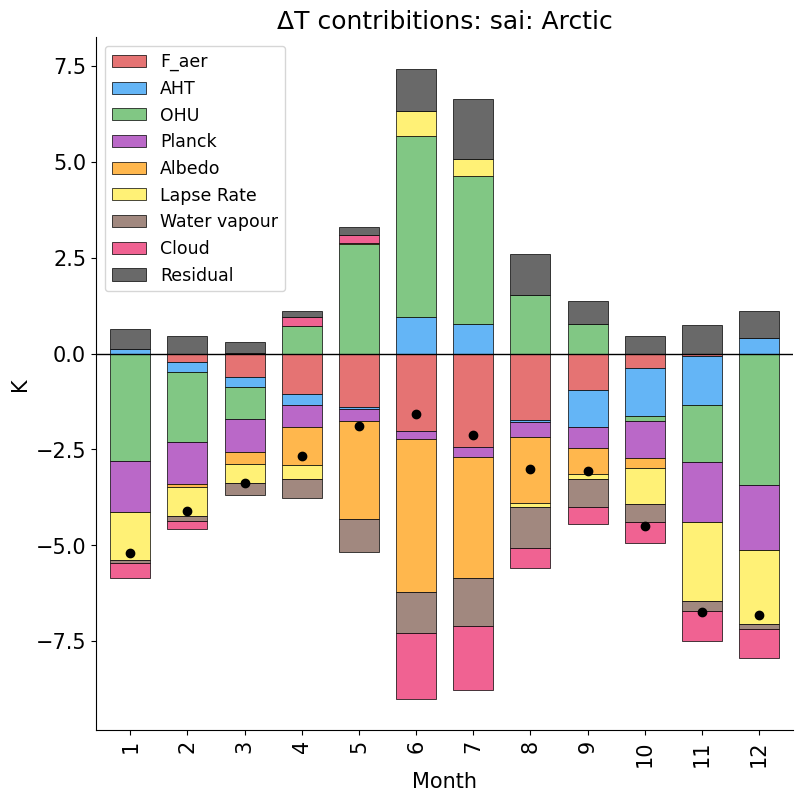

In [24]:
# quick example plot
scen, region = 'sai', 'Arctic'
df = pd.DataFrame(get_delta_T_contribs_dict(scen, region))

df['Month'] = Rs_dict[scen][region].time.values
total_T_contribs = df.drop(columns=['Month']).sum(axis=1)
residuals = deltas_dict[scen][region].tas.values - total_T_contribs
df['Residual'] = residuals

df_rn = df.rename(columns=process_labels) # full words for labels

fig, ax = plt.subplots(1, 1, figsize = (9, 9))#, sharey=True)
i=0
df_rn.plot(kind = "bar",
        x='Month',
        stacked = True,
        ax = ax,
        width = 0.7,
        edgecolor = "black", lw=0.5,
        color=[color_scheme[col] for col in df.drop(columns=['Month']).columns])
ax.scatter(df['Month']-1, deltas_dict[scen][region].tas.values, c='black')
#ax.scatter(df['Month']-1, total_T_contribs, c='red', marker='_')
ax.set_ylabel('K')
ax.axhline(y=0, c='black', lw=1)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.legend(fontsize='small', loc='upper left', ncols=1)
ax.set_title('ΔT contribitions: {s}: {r}'.format(s=scen, r=region))

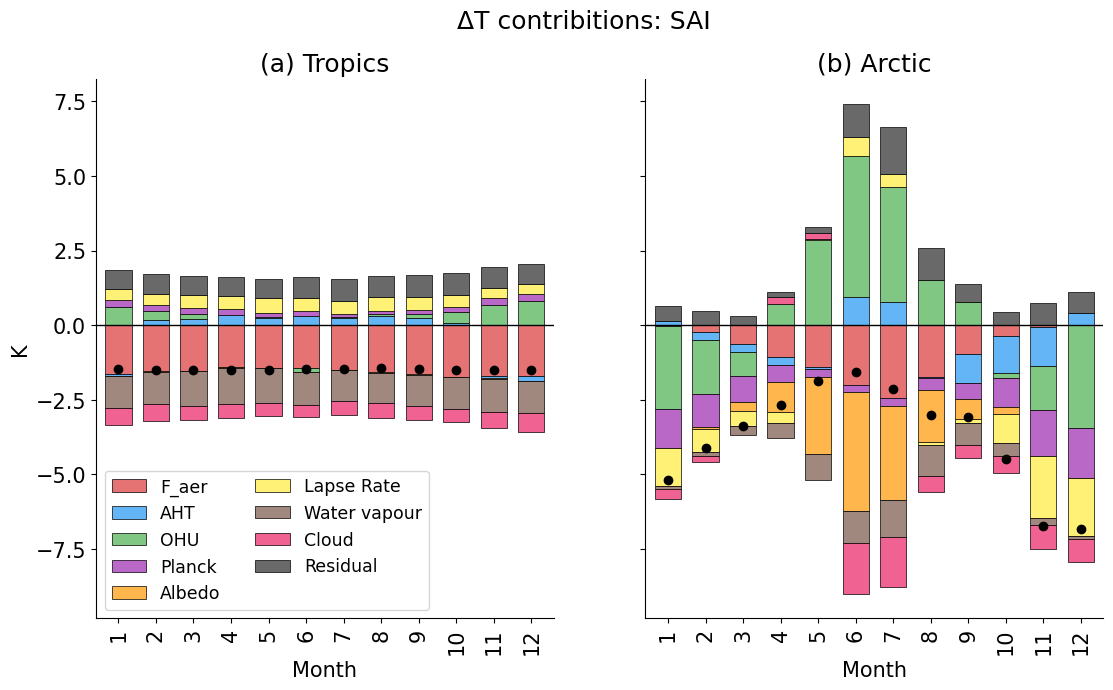

In [25]:
### now plot for both regions:

fig, axs = plt.subplots(1, 2, figsize = (13, 7),
                       sharey=True, sharex=True)

scen = 'sai'
titles = ['(a) Tropics', '(b) Arctic']
i=0
for region in ['Tropics', 'Arctic']:

    df = pd.DataFrame(get_delta_T_contribs_dict(scen, region))
    df['Month'] = Rs_dict[scen][region].time.values
    total_T_contribs = df.drop(columns=['Month']).sum(axis=1)
    residuals = deltas_dict[scen][region].tas.values - total_T_contribs
    df['Residual'] = residuals
    df_rn = df.rename(columns=process_labels)
    ax = axs[i]
    
    df_rn.plot(kind = "bar",
            x='Month',
            stacked = True,
            ax = ax,
            width = 0.7,
            edgecolor = "black", lw=0.5, legend=False,
            color=[color_scheme[col] for col in df.drop(columns=['Month']).columns])
    
    ax.scatter(df['Month']-1, deltas_dict[scen][region].tas.values, c='black')
    #ax.scatter(df['Month']-1, total_T_contribs, c='red', marker='_')
    ax.set_ylabel('K')
    ax.axhline(y=0, c='black', lw=1)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_title(titles[i])
    i=i+1

axs[0].legend(fontsize='small', loc='lower left', ncols=2)
plt.suptitle('ΔT contribitions: SAI')

plt.savefig('figures/Arctic_and_tropical_cooling_contribs.jpg', dpi=300, bbox_inches='tight')

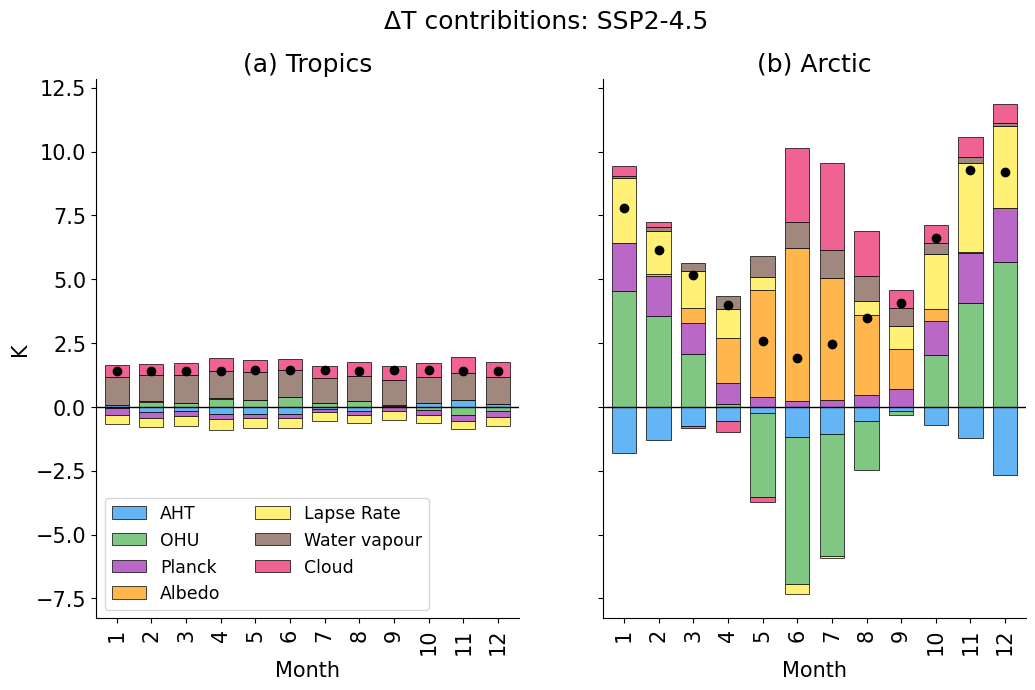

In [26]:
### note - can't do residuals, total T or forcing for SSP cause we dont have it

fig, axs = plt.subplots(1, 2, figsize = (12, 7),
                       sharey=True, sharex=True)

scen = 'ssp'
i=0
titles = ['(a) Tropics', '(b) Arctic']
for region in ['Tropics', 'Arctic']:

    df = pd.DataFrame(get_delta_T_contribs_dict(scen, region))
    df['Month'] = Rs_dict[scen][region].time.values
    df_rn = df.rename(columns=process_labels)
    #df = df.drop(columns=['F'])
    #total_T_contribs = df.drop(columns=['Month']).sum(axis=1)
    #residuals = deltas_dict[scen][region].tas.values - total_T_contribs
    #df['Residual'] = residuals
    
    ax = axs[i]
    
    df_rn.plot(kind = "bar",
            x='Month',
            stacked = True,
            ax = ax,
            width = 0.7,
            edgecolor = "black", lw=0.5, legend=False,
            color=[color_scheme[col] for col in df.drop(columns=['Month']).columns])
    ax.scatter(df['Month']-1, deltas_dict[scen][region].tas.values, c='black')
    #ax.scatter(df['Month']-1, total_T_contribs, c='red', marker='_')
    ax.set_ylabel('K')
    ax.axhline(y=0, c='black', lw=1)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_title(titles[i])
    
    i=i+1

axs[0].legend(fontsize='small', loc='lower left', ncols=2)
plt.suptitle('ΔT contribitions: SSP2-4.5')

plt.savefig('figures/Arctic_and_tropical_warming_contribs.jpg', dpi=300, bbox_inches='tight')

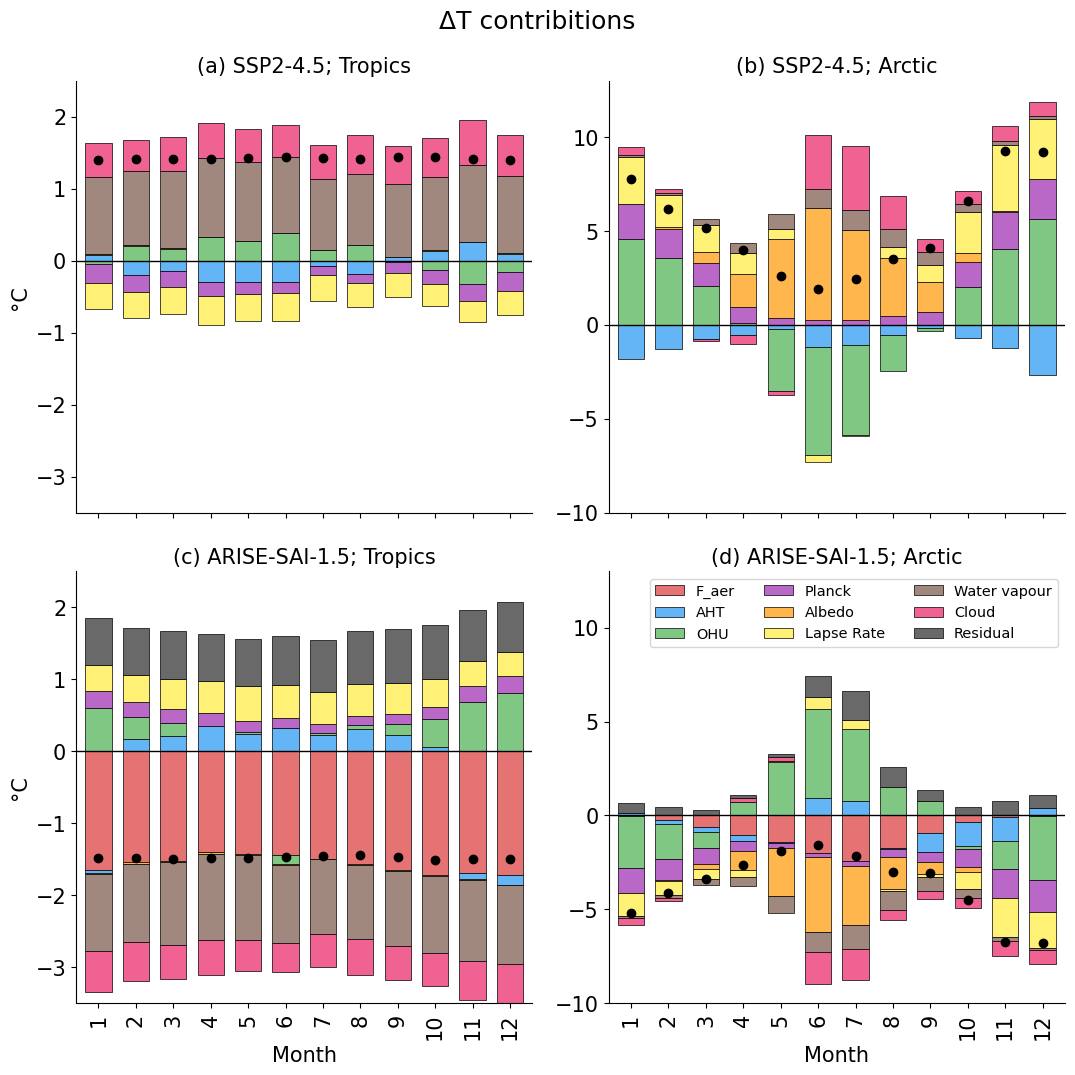

In [27]:
### combine the two plots above into one fig:

fig, axs = plt.subplots(2, 2, figsize = (11, 11), sharey=False, sharex=True)


scen = 'sai'
titles = ['(a) SSP2-4.5; Tropics', '(b) SSP2-4.5; Arctic',
          '(c) ARISE-SAI-1.5; Tropics', '(d) ARISE-SAI-1.5; Arctic']

ylims = {'Tropics':[-3.5, 2.5], 'Arctic':[-10, 13]}
i, j, k = 0, 0, 0
for scen in ['ssp', 'sai']:
    j=0
    for region in ['Tropics', 'Arctic']:

        df = pd.DataFrame(get_delta_T_contribs_dict(scen, region))
        df['Month'] = Rs_dict[scen][region].time.values

        if scen == 'sai':
            total_T_contribs = df.drop(columns=['Month']).sum(axis=1)
            residuals = deltas_dict[scen][region].tas.values - total_T_contribs
            df['Residual'] = residuals
        df_rn = df.rename(columns=process_labels)

        ax = axs[i, j]
        
        df_rn.plot(kind = "bar",
                x='Month',
                stacked = True,
                ax = ax,
                width = 0.7,
                edgecolor = "black", lw=0.5, legend=False,
                color=[color_scheme[col] for col in df.drop(columns=['Month']).columns])
        
        ax.scatter(df['Month']-1, deltas_dict[scen][region].tas.values, c='black')
        #ax.scatter(df['Month']-1, total_T_contribs, c='red', marker='_')
        if region == 'Tropics':
            ax.set_ylabel('°C')
        ax.axhline(y=0, c='black', lw=1)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.set_title(titles[k], fontsize='medium')
        ax.set_ylim(ylims[region])
        j=j+1
        k=k+1
    i=i+1


axs[1,1].legend(fontsize='x-small', loc='upper right', ncols=3)
plt.suptitle('ΔT contribitions', fontsize='large')
plt.tight_layout()
plt.savefig('figures/Arctic_and_tropical_warming_and_cooling_contribs.jpg', dpi=300, bbox_inches='tight')

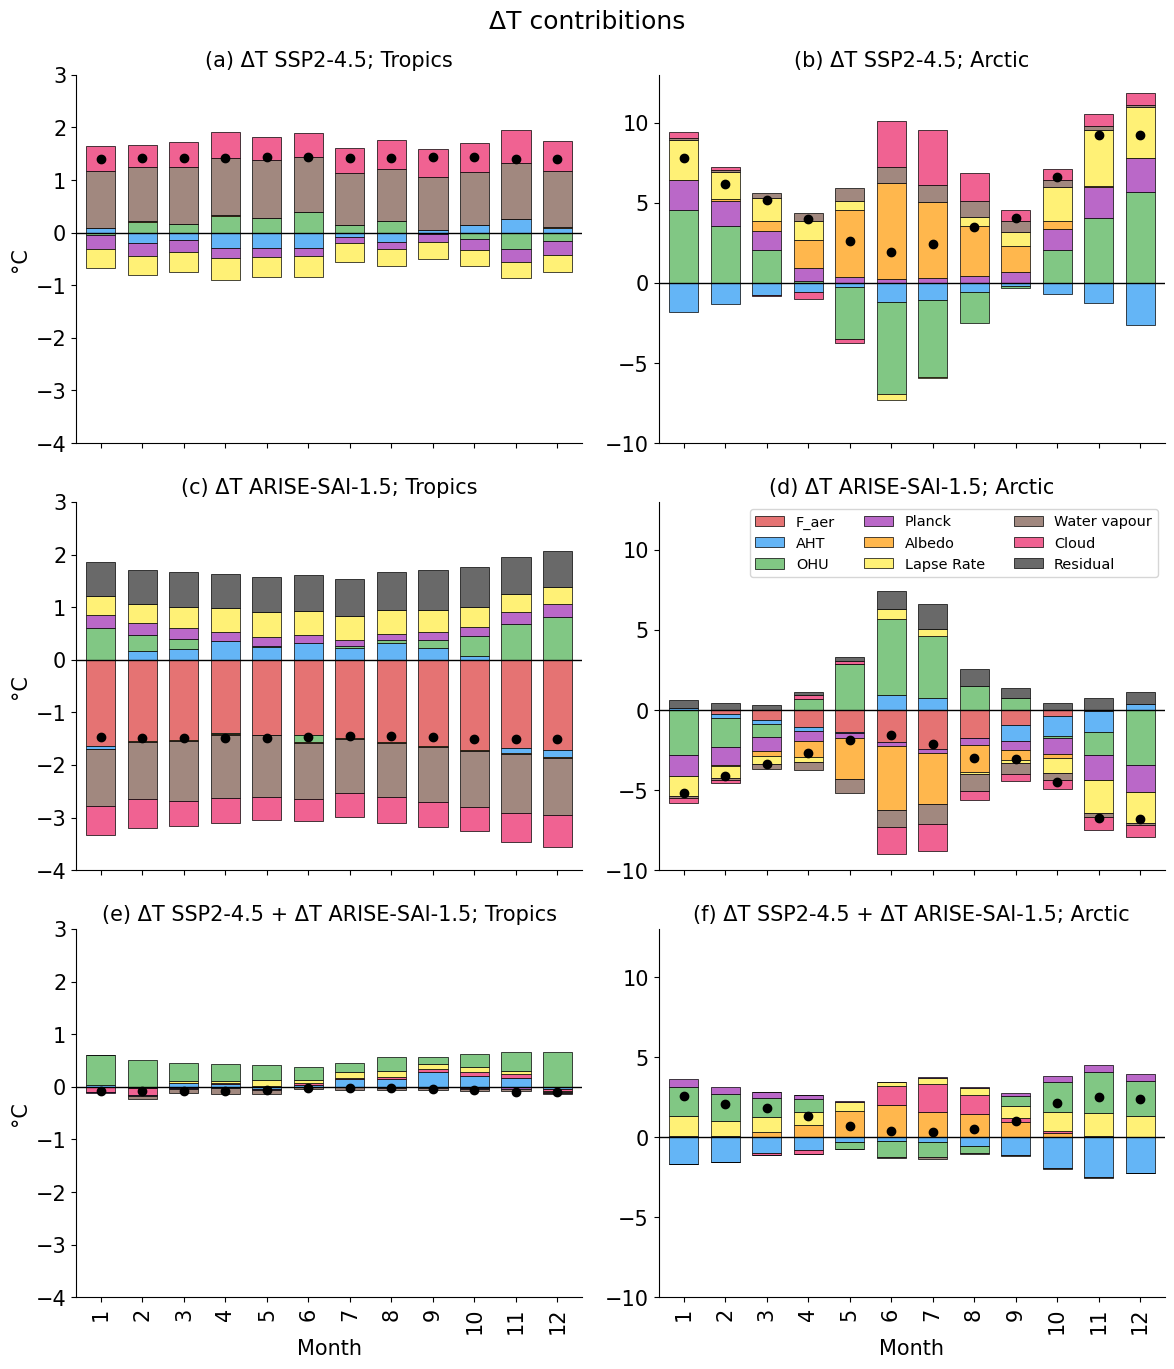

In [28]:
### final version, with difference between SSP245 changes and SAI changes, as a third row: 

### combine the two plots above into one fig:

fig, axs = plt.subplots(3, 2, figsize = (12, 14), sharey=False, sharex=True)


scen = 'sai'
titles = ['(a) ΔT SSP2-4.5; Tropics', '(b) ΔT SSP2-4.5; Arctic',
          '(c) ΔT ARISE-SAI-1.5; Tropics', '(d) ΔT ARISE-SAI-1.5; Arctic', 
          '(e) ΔT SSP2-4.5 + ΔT ARISE-SAI-1.5; Tropics', '(f) ΔT SSP2-4.5 + ΔT ARISE-SAI-1.5; Arctic']

ylims = {'Tropics':[-3.75, 2.75], 'Arctic':[-10, 13]}
ylims = {'Tropics':[-4, 3], 'Arctic':[-10, 13]}
i, j, k = 0, 0, 0
for scen in ['ssp', 'sai']:
    j=0
    for region in ['Tropics', 'Arctic']:

        df = pd.DataFrame(get_delta_T_contribs_dict(scen, region))
        df['Month'] = Rs_dict[scen][region].time.values

        if scen == 'sai':
            total_T_contribs = df.drop(columns=['Month']).sum(axis=1)
            residuals = deltas_dict[scen][region].tas.values - total_T_contribs
            df['Residual'] = residuals
        df_rn = df.rename(columns=process_labels)

        ax = axs[i, j]
        
        df_rn.plot(kind = "bar",
                x='Month',
                stacked = True,
                ax = ax,
                width = 0.7,
                edgecolor = "black", lw=0.5, legend=False,
                color=[color_scheme[col] for col in df.drop(columns=['Month']).columns])
        
        ax.scatter(df['Month']-1, deltas_dict[scen][region].tas.values, c='black')
        #ax.scatter(df['Month']-1, total_T_contribs, c='red', marker='_')
        if region == 'Tropics':
            ax.set_ylabel('°C')
        ax.axhline(y=0, c='black', lw=1)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.set_title(titles[k], fontsize='medium')
        ax.set_ylim(ylims[region])
        j=j+1
        k=k+1
    i=i+1

axs[1,1].legend(fontsize='x-small', loc='upper right', ncols=3)

j=0
# now do the difference plot:
for region in ['Tropics', 'Arctic']:
    df_sai, df_ssp = pd.DataFrame(get_delta_T_contribs_dict('sai', region)), pd.DataFrame(get_delta_T_contribs_dict('ssp', region))
    df = df_ssp + df_sai
    df['Month'] = Rs_dict[scen][region].time.values
    df_rn = df.rename(columns=process_labels)
    ax = axs[2, j]
    df_rn.plot(kind = "bar",
            x='Month',
            stacked = True,
            ax = ax,
            width = 0.7,
            edgecolor = "black", lw=0.5, legend=False,
            color=[color_scheme[col] for col in df.drop(columns=['Month']).columns])
    
    ax.scatter(df['Month']-1, (deltas_dict['ssp'][region].tas + deltas_dict['sai'][region].tas).values, c='black')
    #ax.scatter(df['Month']-1, total_T_contribs, c='red', marker='_')
    if region == 'Tropics':
        ax.set_ylabel('°C')
    ax.axhline(y=0, c='black', lw=1)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_title(titles[k], fontsize='medium')
    ax.set_ylim(ylims[region])
    j=j+1
    k=k+1


plt.suptitle('ΔT contribitions', fontsize='large')
plt.tight_layout()
plt.savefig('figures/Arctic_and_tropical_warming_and_cooling_contribs_plus_deltas.jpg', dpi=300, bbox_inches='tight')

In [29]:
df_sai, df_ssp = pd.DataFrame(get_delta_T_contribs_dict('sai', region)), pd.DataFrame(get_delta_T_contribs_dict('ssp', region))

In [30]:
"""

fig, axs = plt.subplots(1, 2, figsize = (13, 7),
                       sharey=True, sharex=True)

scen = 'sai_vs_baseline'
titles = ['(a) Tropics', '(b) Arctic']
i=0
for region in ['Tropics', 'Arctic']:

    df = pd.DataFrame(get_delta_T_contribs_dict(scen, region))
    df['Month'] = Rs_dict[scen][region].time.values
    #total_T_contribs = df.drop(columns=['Month']).sum(axis=1)
    #residuals = deltas_dict[scen][region].tas.values - total_T_contribs
    #df['Residual'] = residuals
    df_rn = df.rename(columns=process_labels)
    ax = axs[i]
    
    df_rn.plot(kind = "bar",
            x='Month',
            stacked = True,
            ax = ax,
            width = 0.7,
            edgecolor = "black", lw=0.5, legend=False,
            color=[color_scheme[col] for col in df.drop(columns=['Month']).columns])
    
    ax.scatter(df['Month']-1, deltas_dict[scen][region].tas.values, c='black')
    #ax.scatter(df['Month']-1, total_T_contribs, c='red', marker='_')
    ax.set_ylabel('K')
    ax.axhline(y=0, c='black', lw=1)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_title(titles[i])
    i=i+1

axs[0].legend(fontsize='small', loc='lower left', ncols=2)
plt.suptitle('ΔT contribitions: SAI vs baseline')

#plt.savefig('figures/Arctic_and_tropical_cooling_contribs.jpg', dpi=300, bbox_inches='tight')
"""

'\n\nfig, axs = plt.subplots(1, 2, figsize = (13, 7),\n                       sharey=True, sharex=True)\n\nscen = \'sai_vs_baseline\'\ntitles = [\'(a) Tropics\', \'(b) Arctic\']\ni=0\nfor region in [\'Tropics\', \'Arctic\']:\n\n    df = pd.DataFrame(get_delta_T_contribs_dict(scen, region))\n    df[\'Month\'] = Rs_dict[scen][region].time.values\n    #total_T_contribs = df.drop(columns=[\'Month\']).sum(axis=1)\n    #residuals = deltas_dict[scen][region].tas.values - total_T_contribs\n    #df[\'Residual\'] = residuals\n    df_rn = df.rename(columns=process_labels)\n    ax = axs[i]\n    \n    df_rn.plot(kind = "bar",\n            x=\'Month\',\n            stacked = True,\n            ax = ax,\n            width = 0.7,\n            edgecolor = "black", lw=0.5, legend=False,\n            color=[color_scheme[col] for col in df.drop(columns=[\'Month\']).columns])\n    \n    ax.scatter(df[\'Month\']-1, deltas_dict[scen][region].tas.values, c=\'black\')\n    #ax.scatter(df[\'Month\']-1, total_T_

In [31]:
scen = 'sai'
df_t = pd.DataFrame(get_delta_T_contribs_dict(scen, 'Tropics')).mean()

list(df_t)

[-1.5653600604738382,
 0.15658759193395932,
 0.25685351416774527,
 0.17785054469805647,
 -0.01580902085978278,
 0.4099287905403841,
 -1.0958377538788453,
 -0.49489595861259184]

In [32]:
df_t

F        -1.565360
AHT       0.156588
OHU       0.256854
Planck    0.177851
Alb      -0.015809
LR        0.409929
WV       -1.095838
Cloud    -0.494896
dtype: float64

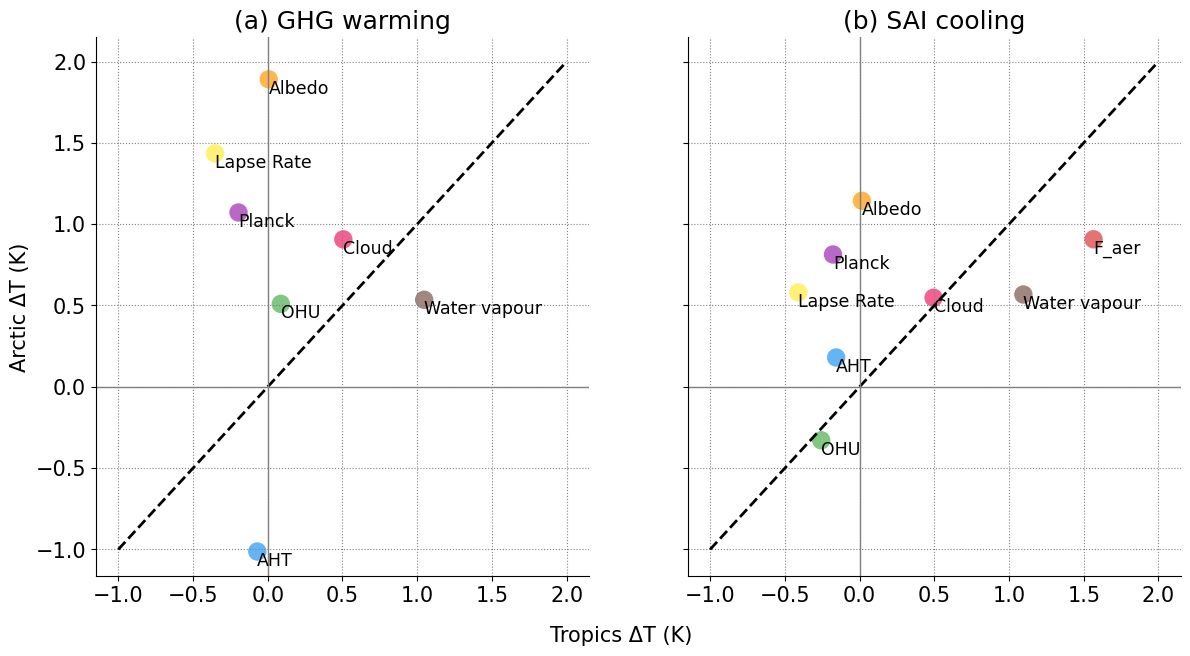

In [33]:
## plot the arctic vs tropical warming contributions under ssp and sai


### now plot for both regions:

fig, axs = plt.subplots(1, 2, figsize = (14, 7),
                       sharey=True, sharex=True)
l=0
titles=['(a) GHG warming', '(b) SAI cooling']
for scen in ['ssp', 'sai']:
    ax = axs[l]
    line = [-1, 2]
    ax.plot(line, line, c='black', linewidth=2, linestyle='--')
    ax.grid(ls='dotted', c='gray')
    ax.axhline(0, c='gray', linewidth=1)
    ax.axvline(0, c='gray', linewidth=1)
 
    df_t = pd.DataFrame(get_delta_T_contribs_dict(scen, 'Tropics')).mean()
    df_a = pd.DataFrame(get_delta_T_contribs_dict(scen, 'Arctic')).mean()
    
    if scen == 'ssp':
        ax.scatter(df_t, df_a, s=150, c=[color_scheme[x] for x in df_t.keys()])
        for i, txt in enumerate(df_t.keys()):
            ax.annotate(process_labels[txt], (list(df_t)[i], list(df_a)[i]), va='top', ha='left', fontsize='small')
    elif scen == 'sai':
        ax.scatter(-df_t, -df_a, s=150, c=[color_scheme[x] for x in df_t.keys()])
        for i, txt in enumerate(df_t.keys()):
            ax.annotate(process_labels[txt], (-list(df_t)[i], -list(df_a)[i]), va='top', ha='left', fontsize='small')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    ax.set_title(titles[l])
    
    l=l+1

axs[0].set_ylabel('Arctic ΔT (K)', fontsize='medium')
fig.supxlabel('Tropics ΔT (K)', fontsize='medium')
plt.savefig('figures/Arctic_vs_tropical_warming_and_cooling_contribs.jpg', dpi=300, bbox_inches='tight')

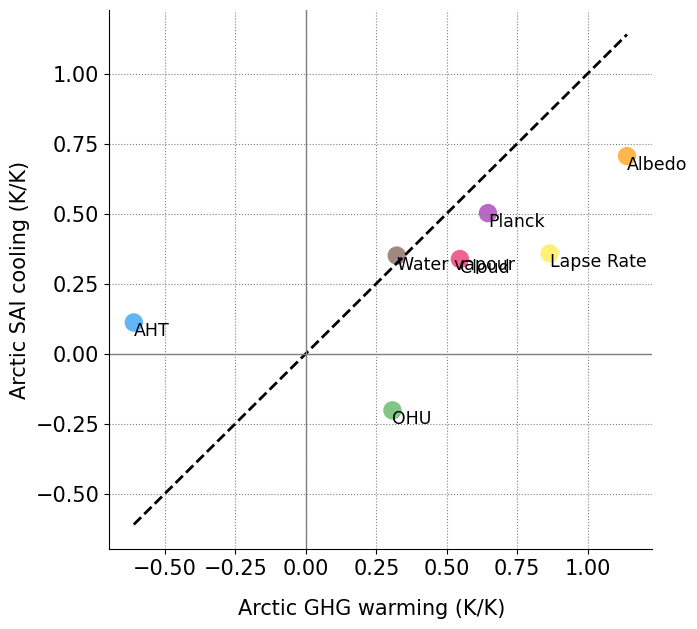

In [34]:

## plot the arctic warming vs arctic cooling contributions under sai

region = 'Arctic'
fig, ax = plt.subplots(1, 1, figsize = (7, 7))

df_x = pd.DataFrame(get_delta_T_contribs_dict('ssp', region)).mean()
df_y = pd.DataFrame(get_delta_T_contribs_dict('sai', region)).mean().drop('F')

# normalise by global warming/cooling (this also takes care of the sign): 
df_x = df_x/QACC_utils.calc_spatial_mean(Rs_dict['ssp']['Spatial'].delta_TS, 'lon', 'lat').mean().item()
df_y = df_y/QACC_utils.calc_spatial_mean(Rs_dict['sai']['Spatial'].delta_TS, 'lon', 'lat').mean().item()


line = [np.min([np.min(df_x), np.min(df_y)]), np.max([np.max(df_x), np.max(df_y)])]
ax.plot(line, line, c='black', linewidth=2, linestyle='--')

ax.scatter(df_x, df_y, s=150, c=[color_scheme[x] for x in df_x.keys()])
    
for i, txt in enumerate(df_x.keys()):
    ax.annotate(process_labels[txt], (list(df_x)[i], list(df_y)[i]), va='top', ha='left', fontsize='small')
    
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_title('')
ax.grid(ls='dotted', c='gray')
ax.axhline(0, c='gray', linewidth=1)
ax.axvline(0, c='gray', linewidth=1)
   
ax.set_ylabel('{r} SAI cooling (K/K)'.format(r=region), fontsize='medium')
fig.supxlabel('{r} GHG warming (K/K)'.format(r=region), fontsize='medium')
plt.savefig('figures/{r}_warming_vs_cooling_contribs.jpg'.format(r=region), dpi=300, bbox_inches='tight')

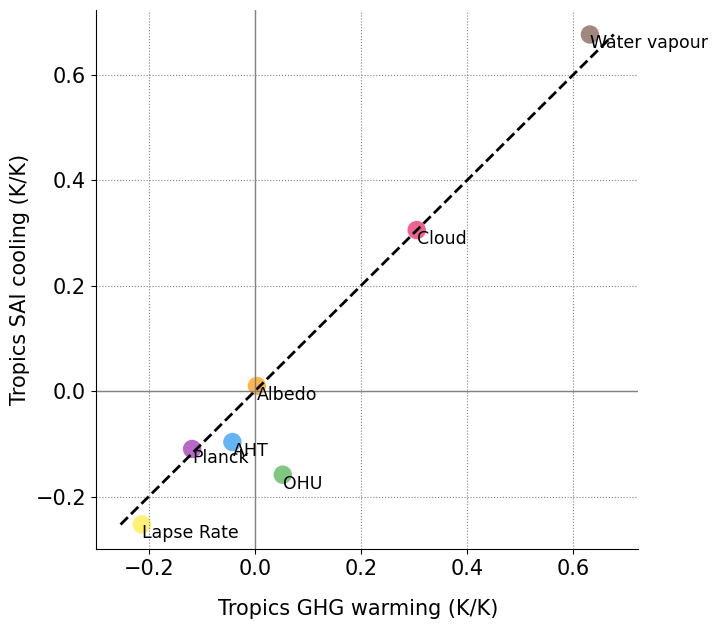

In [35]:

region = 'Tropics'
fig, ax = plt.subplots(1, 1, figsize = (7, 7))

df_x = pd.DataFrame(get_delta_T_contribs_dict('ssp', region)).mean()
df_y = pd.DataFrame(get_delta_T_contribs_dict('sai', region)).mean().drop('F')

# normalise by global warming/cooling (this also takes care of the sign): 
df_x = df_x/QACC_utils.calc_spatial_mean(Rs_dict['ssp']['Spatial'].delta_TS, 'lon', 'lat').mean().item()
df_y = df_y/QACC_utils.calc_spatial_mean(Rs_dict['sai']['Spatial'].delta_TS, 'lon', 'lat').mean().item()

line = [np.min([np.min(df_x), np.min(df_y)]), np.max([np.max(df_x), np.max(df_y)])]
ax.plot(line, line, c='black', linewidth=2, linestyle='--')

ax.scatter(df_x, df_y, s=150, c=[color_scheme[x] for x in df_x.keys()])
    
for i, txt in enumerate(df_x.keys()):
    ax.annotate(process_labels[txt], (list(df_x)[i], list(df_y)[i]), va='top', ha='left', fontsize='small')
    
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_title('')
ax.grid(ls='dotted', c='gray')
ax.axhline(0, c='gray', linewidth=1)
ax.axvline(0, c='gray', linewidth=1)
   
ax.set_ylabel('{r} SAI cooling (K/K)'.format(r=region), fontsize='medium')
fig.supxlabel('{r} GHG warming (K/K)'.format(r=region), fontsize='medium')
plt.savefig('figures/{r}_warming_vs_cooling_contribs.jpg'.format(r=region), dpi=300, bbox_inches='tight')

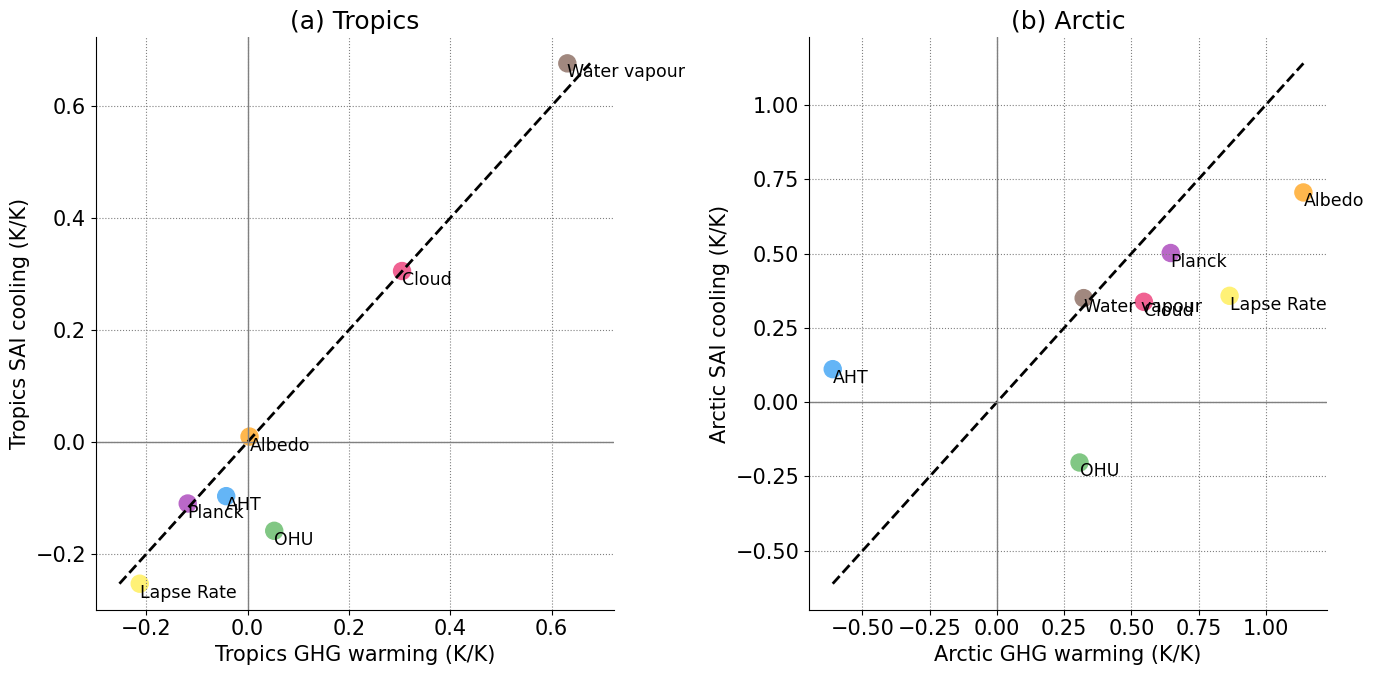

In [36]:
## combine into one:

fig, axs = plt.subplots(1, 2, figsize = (14, 7))

l=0
titles = ['(a) Tropics', '(b) Arctic']
for region in ['Tropics', 'Arctic']:
    ax = axs[l]
 
    
    df_x = pd.DataFrame(get_delta_T_contribs_dict('ssp', region)).mean()
    df_y = pd.DataFrame(get_delta_T_contribs_dict('sai', region)).mean().drop('F')
    
    # normalise by global warming/cooling (this also takes care of the sign): 
    df_x = df_x/QACC_utils.calc_spatial_mean(Rs_dict['ssp']['Spatial'].delta_TS, 'lon', 'lat').mean().item()
    df_y = df_y/QACC_utils.calc_spatial_mean(Rs_dict['sai']['Spatial'].delta_TS, 'lon', 'lat').mean().item()
    
    line = [np.min([np.min(df_x), np.min(df_y)]), np.max([np.max(df_x), np.max(df_y)])]
    ax.plot(line, line, c='black', linewidth=2, linestyle='--')
    
    ax.scatter(df_x, df_y, s=150, c=[color_scheme[x] for x in df_x.keys()])
        
    for i, txt in enumerate(df_x.keys()):
        ax.annotate(process_labels[txt], (list(df_x)[i], list(df_y)[i]), va='top', ha='left', fontsize='small')
        
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_title('')
    ax.grid(ls='dotted', c='gray')
    ax.axhline(0, c='gray', linewidth=1)
    ax.axvline(0, c='gray', linewidth=1)
       
    ax.set_ylabel('{r} SAI cooling (K/K)'.format(r=region), fontsize='medium')
    ax.set_xlabel('{r} GHG warming (K/K)'.format(r=region), fontsize='medium')
    ax.set_title(titles[l])
    l=l+1
plt.tight_layout()   
plt.savefig('figures/Both_regs_warming_vs_cooling_contribs.jpg'.format(r=region), dpi=300, bbox_inches='tight')

In [37]:
QACC_utils.calc_spatial_mean(Rs_dict['ssp']['Spatial'].delta_TS, 'lon', 'lat')

<xarray.DataArray 'delta_TS' (time: 12)> Size: 96B
array([1.78222175, 1.68228831, 1.62034061, 1.51291771, 1.46214411,
       1.54186086, 1.60291362, 1.65729207, 1.6631599 , 1.73997898,
       1.83991389, 1.79901664])
Coordinates:
  * time     (time) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    height   float64 8B ...
    units    <U5 20B ...

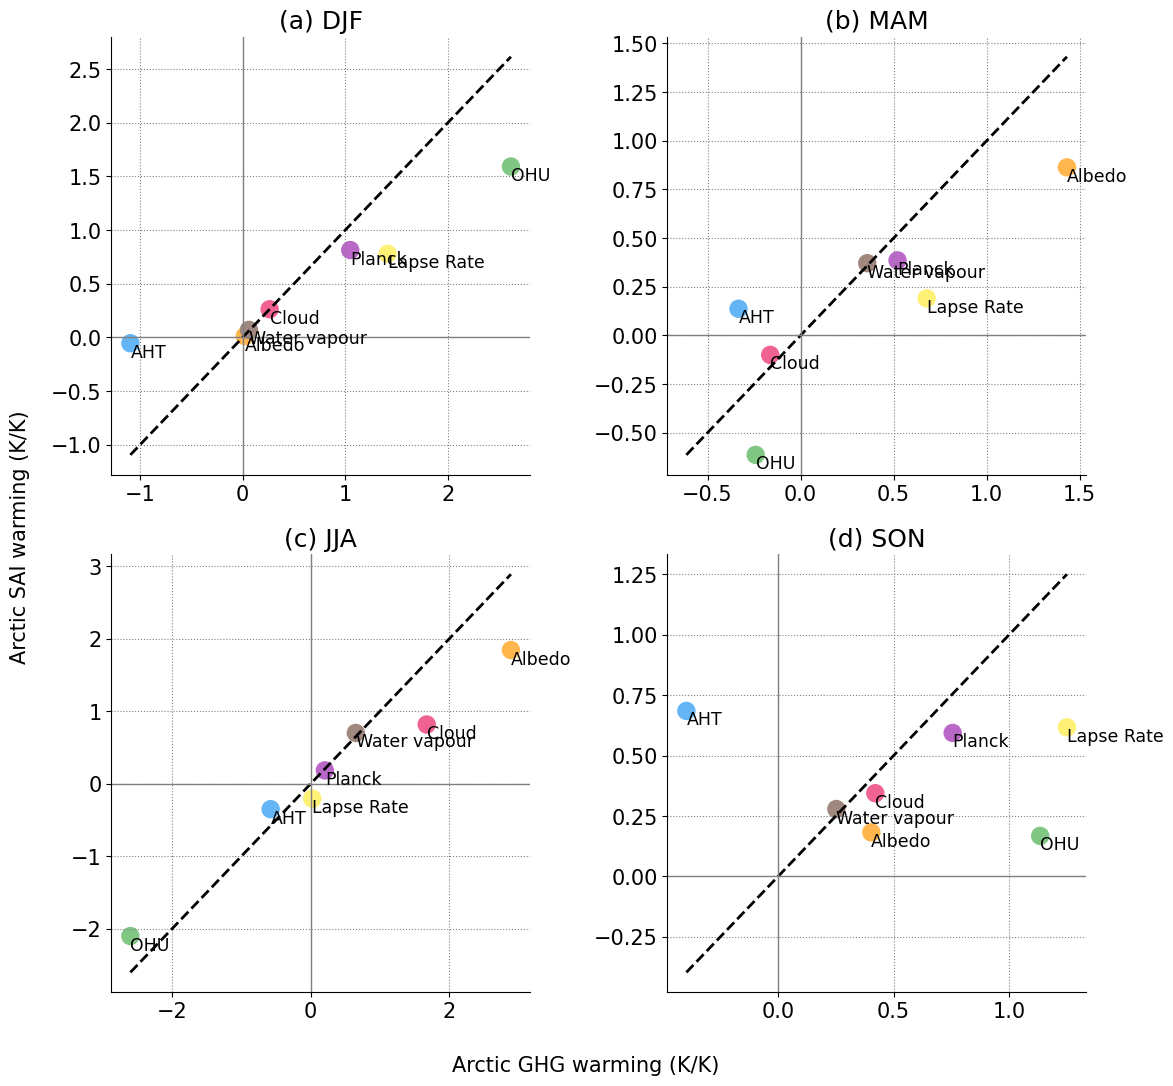

In [38]:
## add a seasonal version of the arctic warming vs cooling plot: 
## combine into one:

fig, axs = plt.subplots(2, 2, figsize = (12, 11), sharey=False, sharex=False)

titles = ['(a) DJF', '(b) MAM', 
          '(c) JJA', '(d) SON']
monthss = [[0,1,11], [2, 3, 4], [5, 6, 7], [8, 9, 10]]
region = 'Arctic'

for l in range(4):
    ax = axs.flatten()[l]
    months = monthss[l]
    
    df_x = pd.DataFrame(get_delta_T_contribs_dict('ssp', region)).iloc[months].mean()
    df_y = pd.DataFrame(get_delta_T_contribs_dict('sai', region)).iloc[months].mean().drop('F')
    
    # normalise by global warming/cooling (this also takes care of the sign): 
    df_x = df_x/QACC_utils.calc_spatial_mean(Rs_dict['ssp']['Spatial'].delta_TS, 'lon', 'lat').isel(time=months).mean().item()
    df_y = df_y/QACC_utils.calc_spatial_mean(Rs_dict['sai']['Spatial'].delta_TS, 'lon', 'lat').isel(time=months).mean().item()
    
    line = [np.min([np.min(df_x), np.min(df_y)]), np.max([np.max(df_x), np.max(df_y)])]
    ax.plot(line, line, c='black', linewidth=2, linestyle='--')
    
    ax.scatter(df_x, df_y, s=150, c=[color_scheme[x] for x in df_x.keys()])
        
    for i, txt in enumerate(df_x.keys()):
        ax.annotate(process_labels[txt], (list(df_x)[i], list(df_y)[i]), va='top', ha='left', fontsize='small')
        
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_title('')
    ax.grid(ls='dotted', c='gray')
    ax.axhline(0, c='gray', linewidth=1)
    ax.axvline(0, c='gray', linewidth=1)
       
    ax.set_title(titles[l])
    l=l+1
fig.supxlabel('{r} GHG warming (K/K)'.format(r=region), fontsize='medium')
fig.supylabel('{r} SAI warming (K/K)'.format(r=region), fontsize='medium')
plt.tight_layout()   
plt.savefig('figures/SAI_warming_vs_cooling_contribs_seasonal.jpg'.format(r=region), dpi=300, bbox_inches='tight')

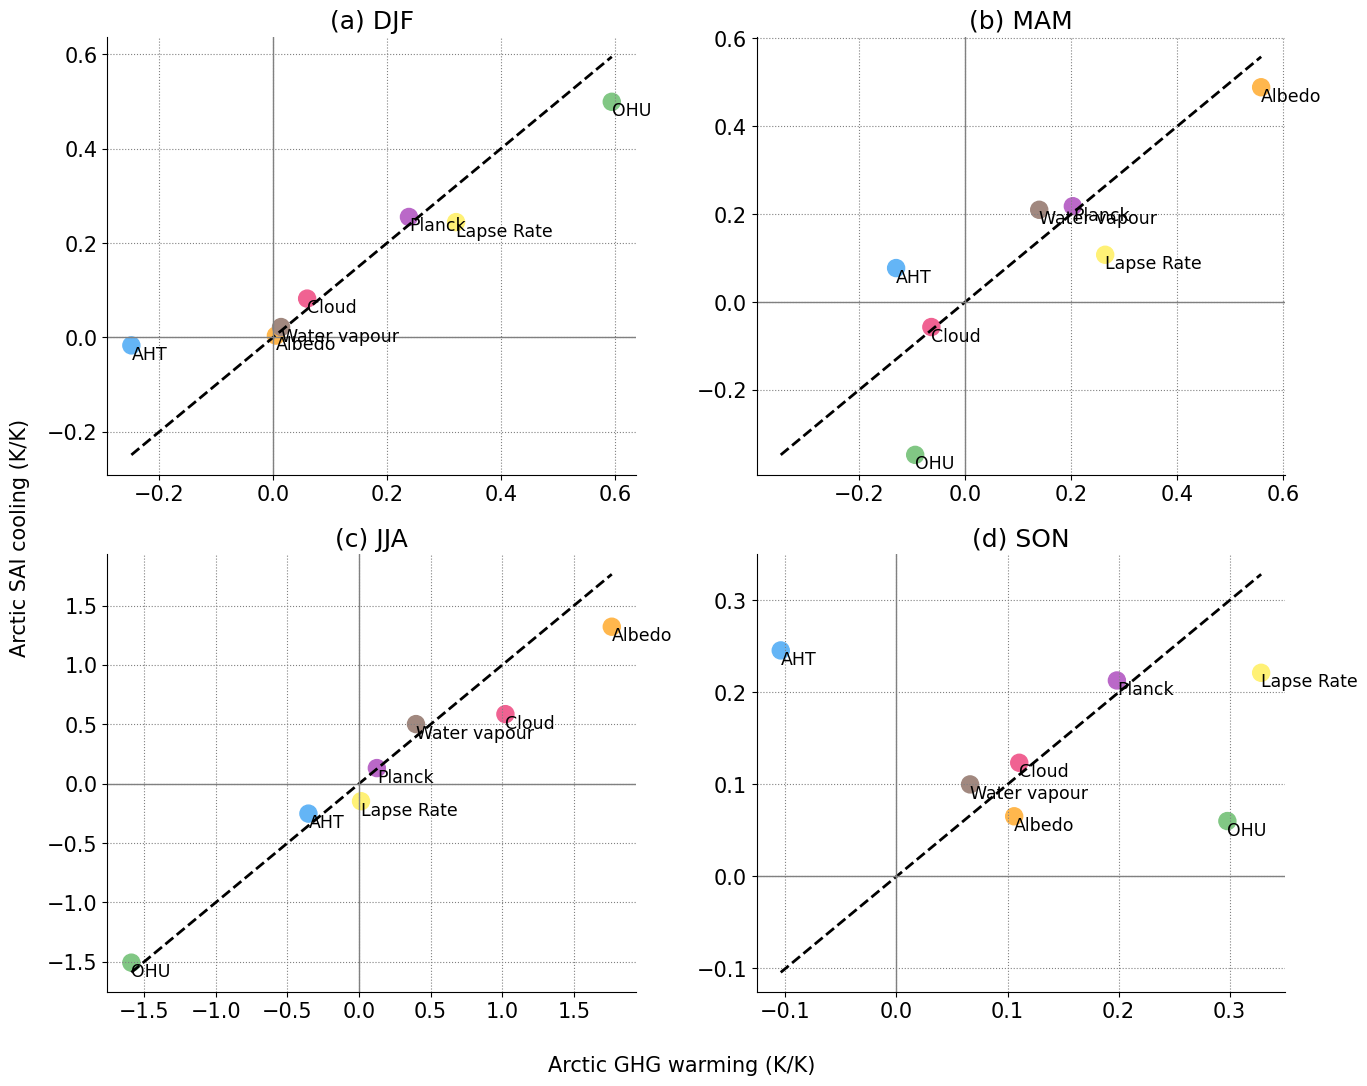

In [39]:
## add a seasonal version of the arctic warming vs cooling plot: 
## combine into one:

fig, axs = plt.subplots(2, 2, figsize = (14, 11), sharey=False, sharex=False)

titles = ['(a) DJF', '(b) MAM', 
          '(c) JJA', '(d) SON']
monthss = [[0,1,11], [2, 3, 4], [5, 6, 7], [8, 9, 10]]
region = 'Arctic'

for l in range(4):
    ax = axs.flatten()[l]
    months = monthss[l]
    
    df_x = pd.DataFrame(get_delta_T_contribs_dict('ssp', region)).iloc[months].mean()
    df_y = pd.DataFrame(get_delta_T_contribs_dict('sai', region)).iloc[months].mean().drop('F')
    
    # normalise by global warming/cooling (this also takes care of the sign): 
    df_x = df_x/Rs_dict['ssp'][region].delta_TS.isel(time=months).mean().item()
    df_y = df_y/Rs_dict['sai'][region].delta_TS.isel(time=months).mean().item()
    
    line = [np.min([np.min(df_x), np.min(df_y)]), np.max([np.max(df_x), np.max(df_y)])]
    ax.plot(line, line, c='black', linewidth=2, linestyle='--')
    
    ax.scatter(df_x, df_y, s=150, c=[color_scheme[x] for x in df_x.keys()])
        
    for i, txt in enumerate(df_x.keys()):
        ax.annotate(process_labels[txt], (list(df_x)[i], list(df_y)[i]), va='top', ha='left', fontsize='small')
        
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_title('')
    ax.grid(ls='dotted', c='gray')
    ax.axhline(0, c='gray', linewidth=1)
    ax.axvline(0, c='gray', linewidth=1)
       
    ax.set_title(titles[l])
    l=l+1
fig.supxlabel('{r} GHG warming (K/K)'.format(r=region), fontsize='medium')
fig.supylabel('{r} SAI cooling (K/K)'.format(r=region), fontsize='medium')
plt.tight_layout()   
plt.savefig('figures/SAI_warming_vs_cooling_contribs_seasonal_normedLocal.jpg'.format(r=region), dpi=300, bbox_inches='tight')

In [40]:
np.min([np.min(df_x), np.min(df_y)])

-0.10421767654034837

In [41]:
process_labels2 = {'F':'F_aer',
                  'AHT':'AHT',
                  'OHU':'OHU',
                  'Planck':'Planck',
                  'Alb':'Albedo',
                  'LR':'Lapse Rate',
                  'WV':'Water\nvapour',
                  'Cloud':'Cloud'}

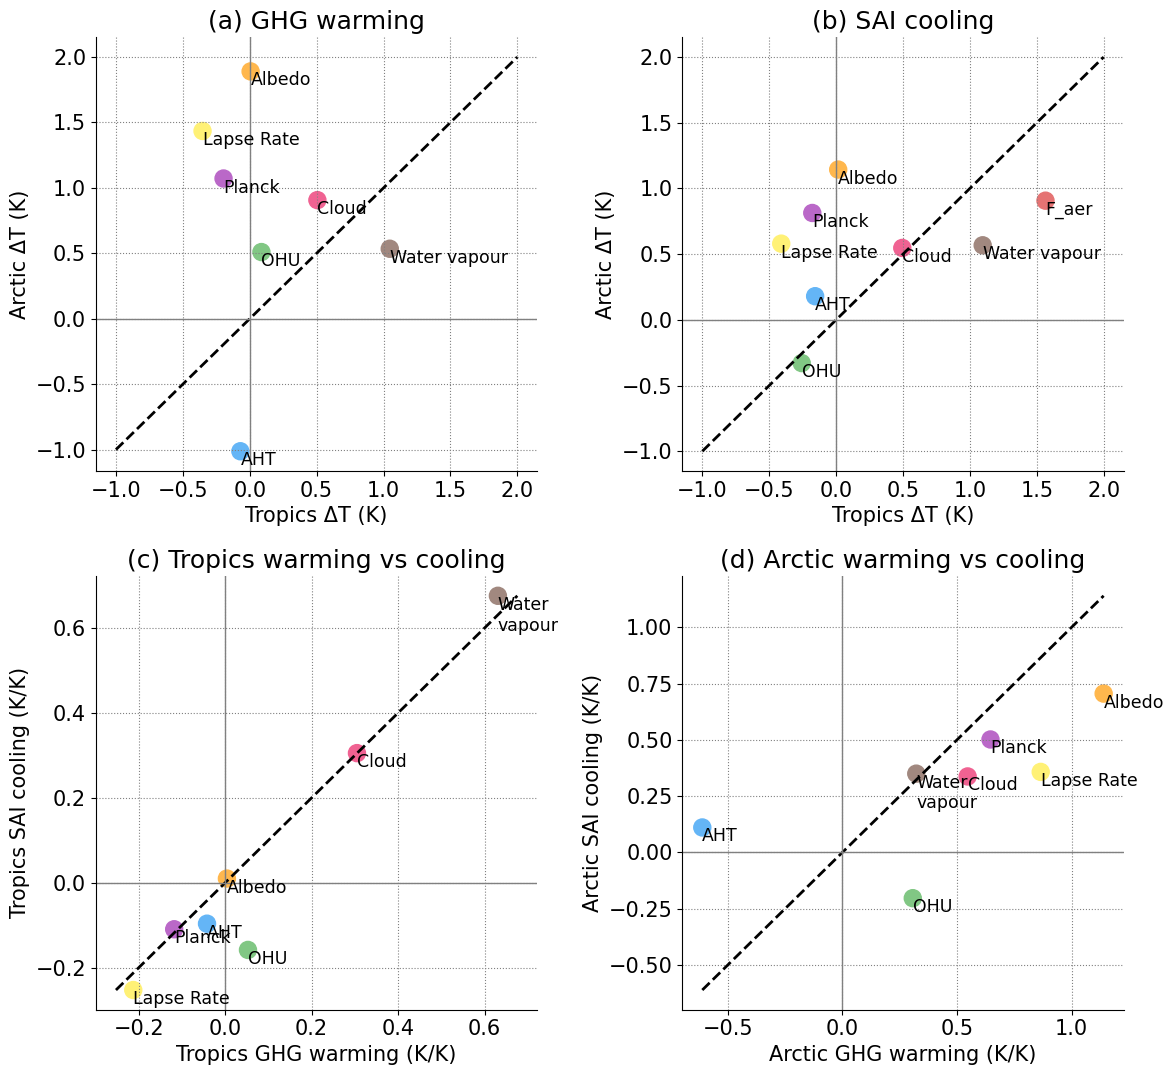

In [42]:
## also combine all the scatters into one: 

## plot the arctic vs tropical warming contributions under ssp and sai


### now plot for both regions:

fig, axs = plt.subplots(2, 2, figsize = (12, 11),)
                       #sharey=True, sharex=True)

l=0
titles=['(a) GHG warming', '(b) SAI cooling']

for scen in ['ssp', 'sai']:
    ax = axs[0, l]
    line = [-1, 2]
    ax.plot(line, line, c='black', linewidth=2, linestyle='--')
    ax.grid(ls='dotted', c='gray')
    ax.axhline(0, c='gray', linewidth=1)
    ax.axvline(0, c='gray', linewidth=1)
 
    df_t = pd.DataFrame(get_delta_T_contribs_dict(scen, 'Tropics')).mean()
    df_a = pd.DataFrame(get_delta_T_contribs_dict(scen, 'Arctic')).mean()
    
    if scen == 'ssp':
        ax.scatter(df_t, df_a, s=150, c=[color_scheme[x] for x in df_t.keys()])
        for i, txt in enumerate(df_t.keys()):
            ax.annotate(process_labels[txt], (list(df_t)[i], list(df_a)[i]), va='top', ha='left', fontsize='small')
    elif scen == 'sai':
        ax.scatter(-df_t, -df_a, s=150, c=[color_scheme[x] for x in df_t.keys()])
        for i, txt in enumerate(df_t.keys()):
            ax.annotate(process_labels[txt], (-list(df_t)[i], -list(df_a)[i]), va='top', ha='left', fontsize='small')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    ax.set_title(titles[l])
    ax.set_xlabel('Tropics ΔT (K)', fontsize='medium')
    ax.set_ylabel('Arctic ΔT (K)', fontsize='medium')
    l=l+1



l=0
titles = ['(c) Tropics warming vs cooling', '(d) Arctic warming vs cooling']
for region in ['Tropics', 'Arctic']:
    ax = axs[1, l]
 
    
    df_x = pd.DataFrame(get_delta_T_contribs_dict('ssp', region)).mean()
    df_y = pd.DataFrame(get_delta_T_contribs_dict('sai', region)).mean().drop('F')
    
    # normalise by global warming/cooling (this also takes care of the sign): 
    df_x = df_x/QACC_utils.calc_spatial_mean(Rs_dict['ssp']['Spatial'].delta_TS, 'lon', 'lat').mean().item()
    df_y = df_y/QACC_utils.calc_spatial_mean(Rs_dict['sai']['Spatial'].delta_TS, 'lon', 'lat').mean().item()
    
    line = [np.min([np.min(df_x), np.min(df_y)]), np.max([np.max(df_x), np.max(df_y)])]
    ax.plot(line, line, c='black', linewidth=2, linestyle='--')
    
    ax.scatter(df_x, df_y, s=150, c=[color_scheme[x] for x in df_x.keys()])
        
    for i, txt in enumerate(df_x.keys()):
        ax.annotate(process_labels2[txt], (list(df_x)[i], list(df_y)[i]), va='top', ha='left', fontsize='small')
        
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_title('')
    ax.grid(ls='dotted', c='gray')
    ax.axhline(0, c='gray', linewidth=1)
    ax.axvline(0, c='gray', linewidth=1)
       
    ax.set_ylabel('{r} SAI cooling (K/K)'.format(r=region), fontsize='medium')
    ax.set_xlabel('{r} GHG warming (K/K)'.format(r=region), fontsize='medium')
    ax.set_title(titles[l])
    l=l+1
plt.tight_layout()   
plt.savefig('figures/all_warming_vs_cooling_contribs.jpg', dpi=300, bbox_inches='tight')

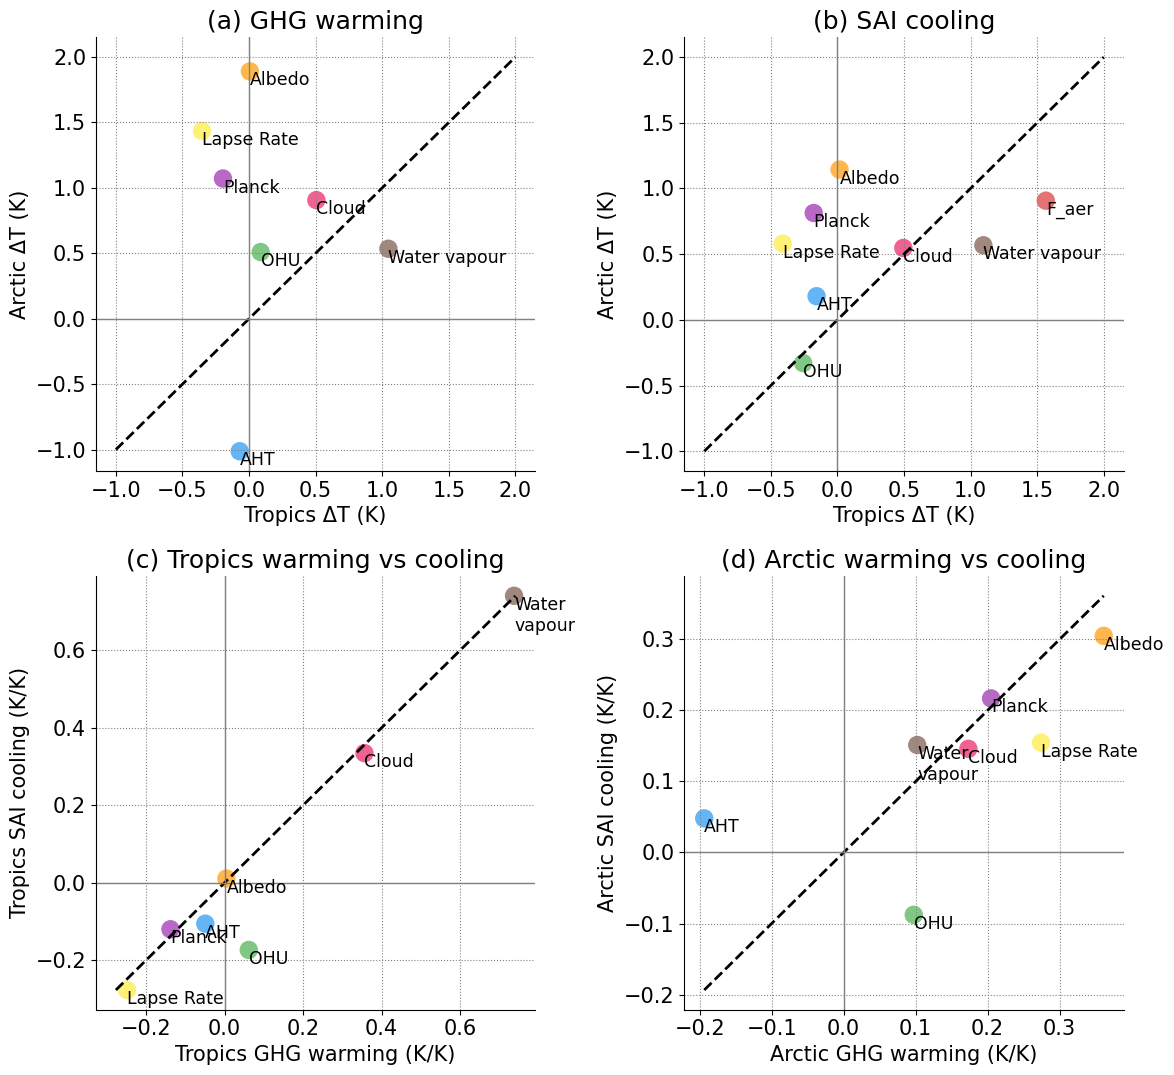

In [43]:
### repeat the above plot but normalised by the LOCAL temp change 

## also combine all the scatters into one: 

## plot the arctic vs tropical warming contributions under ssp and sai


### now plot for both regions:

fig, axs = plt.subplots(2, 2, figsize = (12, 11),)
                       #sharey=True, sharex=True)

l=0
titles=['(a) GHG warming', '(b) SAI cooling']

for scen in ['ssp', 'sai']:
    ax = axs[0, l]
    line = [-1, 2]
    ax.plot(line, line, c='black', linewidth=2, linestyle='--')
    ax.grid(ls='dotted', c='gray')
    ax.axhline(0, c='gray', linewidth=1)
    ax.axvline(0, c='gray', linewidth=1)
 
    df_t = pd.DataFrame(get_delta_T_contribs_dict(scen, 'Tropics')).mean()
    df_a = pd.DataFrame(get_delta_T_contribs_dict(scen, 'Arctic')).mean()
    
    if scen == 'ssp':
        ax.scatter(df_t, df_a, s=150, c=[color_scheme[x] for x in df_t.keys()])
        for i, txt in enumerate(df_t.keys()):
            ax.annotate(process_labels[txt], (list(df_t)[i], list(df_a)[i]), va='top', ha='left', fontsize='small')
    elif scen == 'sai':
        ax.scatter(-df_t, -df_a, s=150, c=[color_scheme[x] for x in df_t.keys()])
        for i, txt in enumerate(df_t.keys()):
            ax.annotate(process_labels[txt], (-list(df_t)[i], -list(df_a)[i]), va='top', ha='left', fontsize='small')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    ax.set_title(titles[l])
    ax.set_xlabel('Tropics ΔT (K)', fontsize='medium')
    ax.set_ylabel('Arctic ΔT (K)', fontsize='medium')
    l=l+1



l=0
titles = ['(c) Tropics warming vs cooling', '(d) Arctic warming vs cooling']
for region in ['Tropics', 'Arctic']:
    ax = axs[1, l]
 
    
    df_x = pd.DataFrame(get_delta_T_contribs_dict('ssp', region)).mean()
    df_y = pd.DataFrame(get_delta_T_contribs_dict('sai', region)).mean().drop('F')
    
    # normalise by local warming or cooling (this also takes care of the sign): 
    df_x = df_x/Rs_dict['ssp'][region].delta_TS.mean().item()
    df_y = df_y/Rs_dict['sai'][region].delta_TS.mean().item()
    
    line = [np.min([np.min(df_x), np.min(df_y)]), np.max([np.max(df_x), np.max(df_y)])]
    ax.plot(line, line, c='black', linewidth=2, linestyle='--')
    
    ax.scatter(df_x, df_y, s=150, c=[color_scheme[x] for x in df_x.keys()])
        
    for i, txt in enumerate(df_x.keys()):
        ax.annotate(process_labels2[txt], (list(df_x)[i], list(df_y)[i]), va='top', ha='left', fontsize='small')
        
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_title('')
    ax.grid(ls='dotted', c='gray')
    ax.axhline(0, c='gray', linewidth=1)
    ax.axvline(0, c='gray', linewidth=1)
       
    ax.set_ylabel('{r} SAI cooling (K/K)'.format(r=region), fontsize='medium')
    ax.set_xlabel('{r} GHG warming (K/K)'.format(r=region), fontsize='medium')
    ax.set_title(titles[l])
    l=l+1
plt.tight_layout()   
plt.savefig('figures/all_warming_vs_cooling_contribs_normedLocal.jpg', dpi=300, bbox_inches='tight')

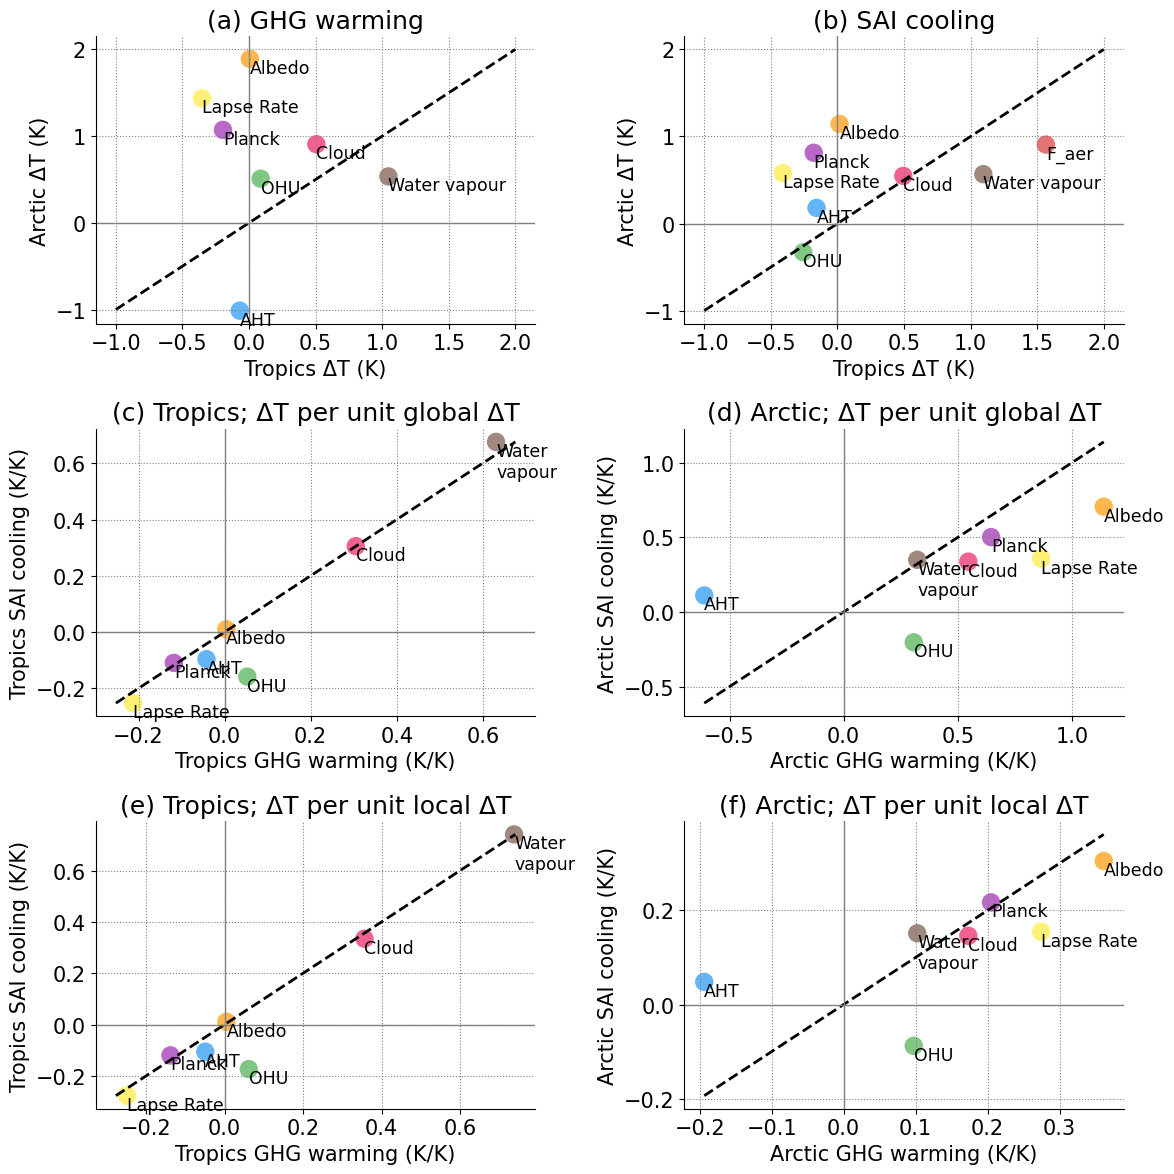

In [44]:
### now combine into one fig: 

### repeat the above plot but normalised by the LOCAL temp change 

## also combine all the scatters into one: 

## plot the arctic vs tropical warming contributions under ssp and sai


### now plot for both regions:

fig, axs = plt.subplots(3, 2, figsize = (12, 12),)
                       #sharey=True, sharex=True)

l=0
titles=['(a) GHG warming', '(b) SAI cooling']

for scen in ['ssp', 'sai']:
    ax = axs[0, l]
    line = [-1, 2]
    ax.plot(line, line, c='black', linewidth=2, linestyle='--')
    ax.grid(ls='dotted', c='gray')
    ax.axhline(0, c='gray', linewidth=1)
    ax.axvline(0, c='gray', linewidth=1)
 
    df_t = pd.DataFrame(get_delta_T_contribs_dict(scen, 'Tropics')).mean()
    df_a = pd.DataFrame(get_delta_T_contribs_dict(scen, 'Arctic')).mean()
    
    if scen == 'ssp':
        ax.scatter(df_t, df_a, s=150, c=[color_scheme[x] for x in df_t.keys()])
        for i, txt in enumerate(df_t.keys()):
            ax.annotate(process_labels[txt], (list(df_t)[i], list(df_a)[i]), va='top', ha='left', fontsize='small')
    elif scen == 'sai':
        ax.scatter(-df_t, -df_a, s=150, c=[color_scheme[x] for x in df_t.keys()])
        for i, txt in enumerate(df_t.keys()):
            ax.annotate(process_labels[txt], (-list(df_t)[i], -list(df_a)[i]), va='top', ha='left', fontsize='small')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    ax.set_title(titles[l])
    ax.set_xlabel('Tropics ΔT (K)', fontsize='medium')
    ax.set_ylabel('Arctic ΔT (K)', fontsize='medium')
    l=l+1
    
l=0
titles = ['(c) Tropics; ΔT per unit global ΔT', '(d) Arctic; ΔT per unit global ΔT']
for region in ['Tropics', 'Arctic']:
    ax = axs[1, l]
 
    
    df_x = pd.DataFrame(get_delta_T_contribs_dict('ssp', region)).mean()
    df_y = pd.DataFrame(get_delta_T_contribs_dict('sai', region)).mean().drop('F')
    
    # normalise by global warming or cooling (this also takes care of the sign): 
    df_x = df_x/QACC_utils.calc_spatial_mean(Rs_dict['ssp']['Spatial'].delta_TS, 'lon', 'lat').mean().item()
    df_y = df_y/QACC_utils.calc_spatial_mean(Rs_dict['sai']['Spatial'].delta_TS, 'lon', 'lat').mean().item()
    
    line = [np.min([np.min(df_x), np.min(df_y)]), np.max([np.max(df_x), np.max(df_y)])]
    ax.plot(line, line, c='black', linewidth=2, linestyle='--')
    
    ax.scatter(df_x, df_y, s=150, c=[color_scheme[x] for x in df_x.keys()])
        
    for i, txt in enumerate(df_x.keys()):
        ax.annotate(process_labels2[txt], (list(df_x)[i], list(df_y)[i]), va='top', ha='left', fontsize='small')
        
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_title('')
    ax.grid(ls='dotted', c='gray')
    ax.axhline(0, c='gray', linewidth=1)
    ax.axvline(0, c='gray', linewidth=1)
       
    ax.set_ylabel('{r} SAI cooling (K/K)'.format(r=region), fontsize='medium')
    ax.set_xlabel('{r} GHG warming (K/K)'.format(r=region), fontsize='medium')
    ax.set_title(titles[l])
    l=l+1


l=0
titles = ['(e) Tropics; ΔT per unit local ΔT', '(f) Arctic; ΔT per unit local ΔT']
for region in ['Tropics', 'Arctic']:
    ax = axs[2, l]
 
    
    df_x = pd.DataFrame(get_delta_T_contribs_dict('ssp', region)).mean()
    df_y = pd.DataFrame(get_delta_T_contribs_dict('sai', region)).mean().drop('F')
    
    df_x = df_x/Rs_dict['ssp'][region].delta_TS.mean().item()
    df_y = df_y/Rs_dict['sai'][region].delta_TS.mean().item()
    
    line = [np.min([np.min(df_x), np.min(df_y)]), np.max([np.max(df_x), np.max(df_y)])]
    ax.plot(line, line, c='black', linewidth=2, linestyle='--')
    
    ax.scatter(df_x, df_y, s=150, c=[color_scheme[x] for x in df_x.keys()])
        
    for i, txt in enumerate(df_x.keys()):
        ax.annotate(process_labels2[txt], (list(df_x)[i], list(df_y)[i]), va='top', ha='left', fontsize='small')
        
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_title('')
    ax.grid(ls='dotted', c='gray')
    ax.axhline(0, c='gray', linewidth=1)
    ax.axvline(0, c='gray', linewidth=1)
       
    ax.set_ylabel('{r} SAI cooling (K/K)'.format(r=region), fontsize='medium')
    ax.set_xlabel('{r} GHG warming (K/K)'.format(r=region), fontsize='medium')
    ax.set_title(titles[l])
    l=l+1
plt.tight_layout()   
plt.savefig('figures/all_warming_vs_cooling_contribs_bothnorms.jpg', dpi=300, bbox_inches='tight')

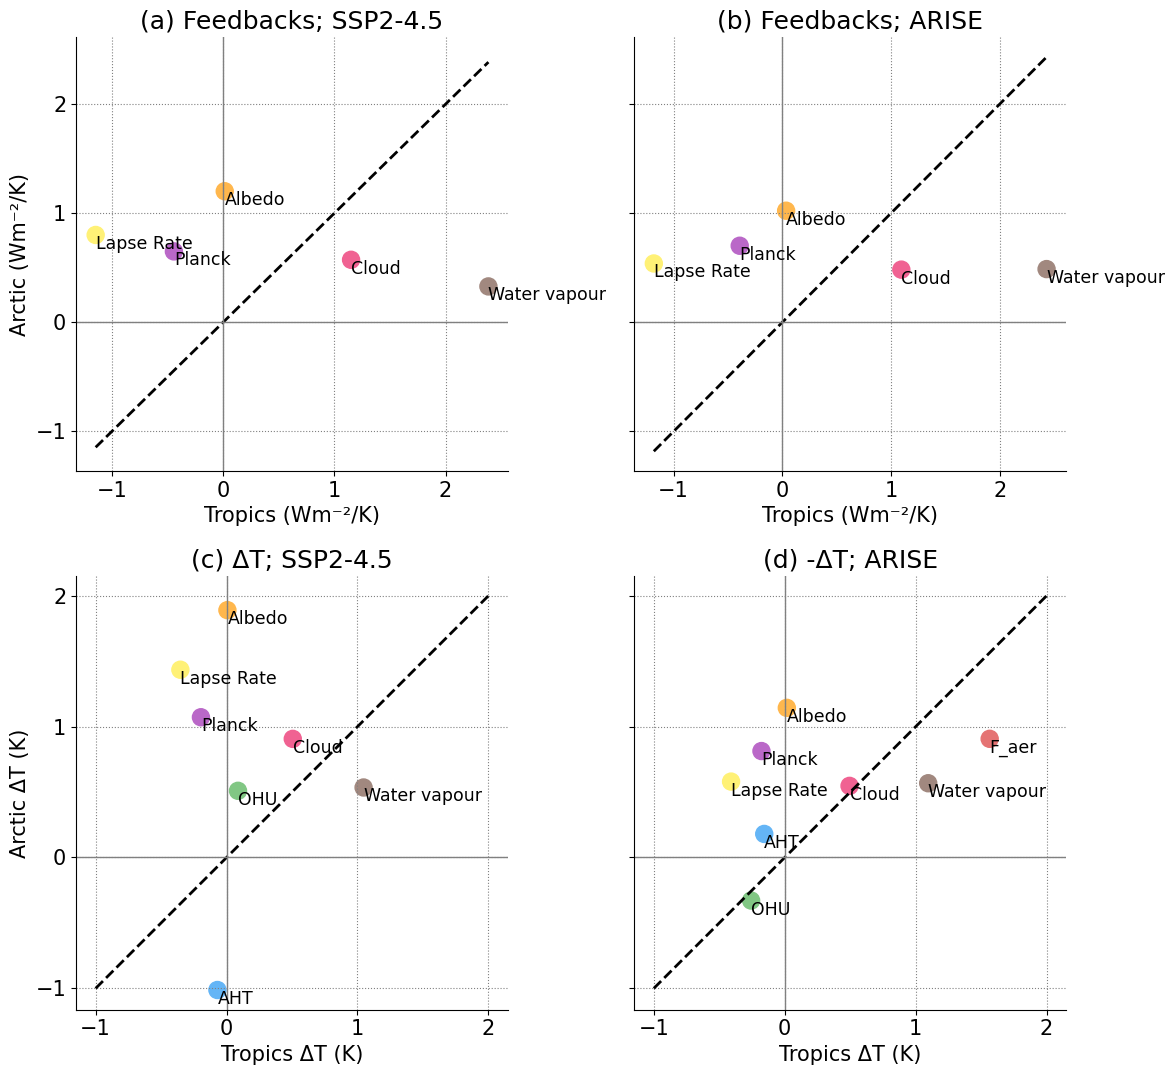

In [45]:
### now do both the feedbacks and temp contributions together, with one plot per format: 

### repeat the above plot but normalised by the LOCAL temp change 

## also combine all the scatters into one: 

## plot the arctic vs tropical warming contributions under ssp and sai


### now plot for both regions:

fig, axs = plt.subplots(2, 2, figsize = (12, 11),
                       sharey='row')#, sharex=True)



l=0
titles=['(a) Feedbacks; SSP2-4.5', '(b) Feedbacks; ARISE']

for scen in ['ssp', 'sai']:
    ax = axs[0, l]

    fs, fs_A, fs_T, labs = [], [], [], []
    for f in ['LR', 'Planck_dash', 'WV', 'Alb']:
        lambda_f_Arctic = Rs_dict[scen]['Arctic'].mean('time')[f].values/Rs_dict[scen]['Arctic'].mean('time')['delta_TS'].values
        lambda_f_Tropics = Rs_dict[scen]['Tropics'].mean('time')[f].values/Rs_dict[scen]['Tropics'].mean('time')['delta_TS'].values
        fs.append(lambda_f_Arctic)
        fs_A.append(lambda_f_Arctic)
        fs.append(lambda_f_Tropics)
        fs_T.append(lambda_f_Tropics)
        labs.append(f)
        #ax.scatter(lambda_f_Tropics, lambda_f_Arctic, label=f, zorder=1000)

    lambda_cloud_Arctic = cloudR_dict[scen]['Arctic'].mean('time').values/Rs_dict[scen]['Arctic'].mean('time')['delta_TS'].values
    lambda_cloud_Tropics = cloudR_dict[scen]['Tropics'].mean('time').values/Rs_dict[scen]['Tropics'].mean('time')['delta_TS'].values

    labs.append('Cloud')
    fs_A.append(lambda_cloud_Arctic)
    fs_T.append(lambda_cloud_Tropics)
    #ax.scatter(lambda_cloud_Arctic, lambda_cloud_Tropics, label='Cloud', zorder=1000)

    ax.scatter(fs_T, fs_A, s=150, c=[color_scheme[x] for x in labs])
    for i, txt in enumerate(labs):
        ax.annotate(process_labels[txt], (fs_T[i], fs_A[i]), va='top', ha='left', fontsize='small')
            
    line = [np.min(fs), np.max(fs)]
    ax.plot(line, line, c='black', linewidth=2, linestyle='--')
    
    ax.grid(ls='dotted', c='gray')
    ax.axhline(0, c='gray', linewidth=1)
    ax.axvline(0, c='gray', linewidth=1)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_title(titles[l])
    ax.set_xticks([-1, 0, 1, 2])
    ax.set_yticks([-1, 0, 1, 2])
    ax.set_xlabel('Tropics (Wm\u207B\u00B2/K)', fontsize='medium')
    if l ==0:
        ax.set_ylabel('Arctic (Wm\u207B\u00B2/K)', fontsize='medium')
    l=l+1


l=0
titles = ['(c) ΔT; SSP2-4.5', '(d) -ΔT; ARISE']
for scen in ['ssp', 'sai']:
    ax = axs[1, l]
    line = [-1, 2]
    ax.plot(line, line, c='black', linewidth=2, linestyle='--')
    ax.grid(ls='dotted', c='gray')
    ax.axhline(0, c='gray', linewidth=1)
    ax.axvline(0, c='gray', linewidth=1)
 
    df_t = pd.DataFrame(get_delta_T_contribs_dict(scen, 'Tropics')).mean()
    df_a = pd.DataFrame(get_delta_T_contribs_dict(scen, 'Arctic')).mean()
    
    if scen == 'ssp':
        ax.scatter(df_t, df_a, s=150, c=[color_scheme[x] for x in df_t.keys()])
        for i, txt in enumerate(df_t.keys()):
            ax.annotate(process_labels[txt], (list(df_t)[i], list(df_a)[i]), va='top', ha='left', fontsize='small')
    elif scen == 'sai':
        ax.scatter(-df_t, -df_a, s=150, c=[color_scheme[x] for x in df_t.keys()])
        for i, txt in enumerate(df_t.keys()):
            ax.annotate(process_labels[txt], (-list(df_t)[i], -list(df_a)[i]), va='top', ha='left', fontsize='small')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_xticks([-1, 0, 1, 2])
    ax.set_yticks([-1, 0, 1, 2])
    ax.set_title(titles[l])
    ax.set_xlabel('Tropics ΔT (K)', fontsize='medium')
    if l ==0:
        ax.set_ylabel('Arctic ΔT (K)', fontsize='medium')
    l=l+1

plt.tight_layout()   
plt.savefig('figures/absolute_Arctic_v_tropics_feedbacks_and_deltaT.jpg', dpi=300, bbox_inches='tight')

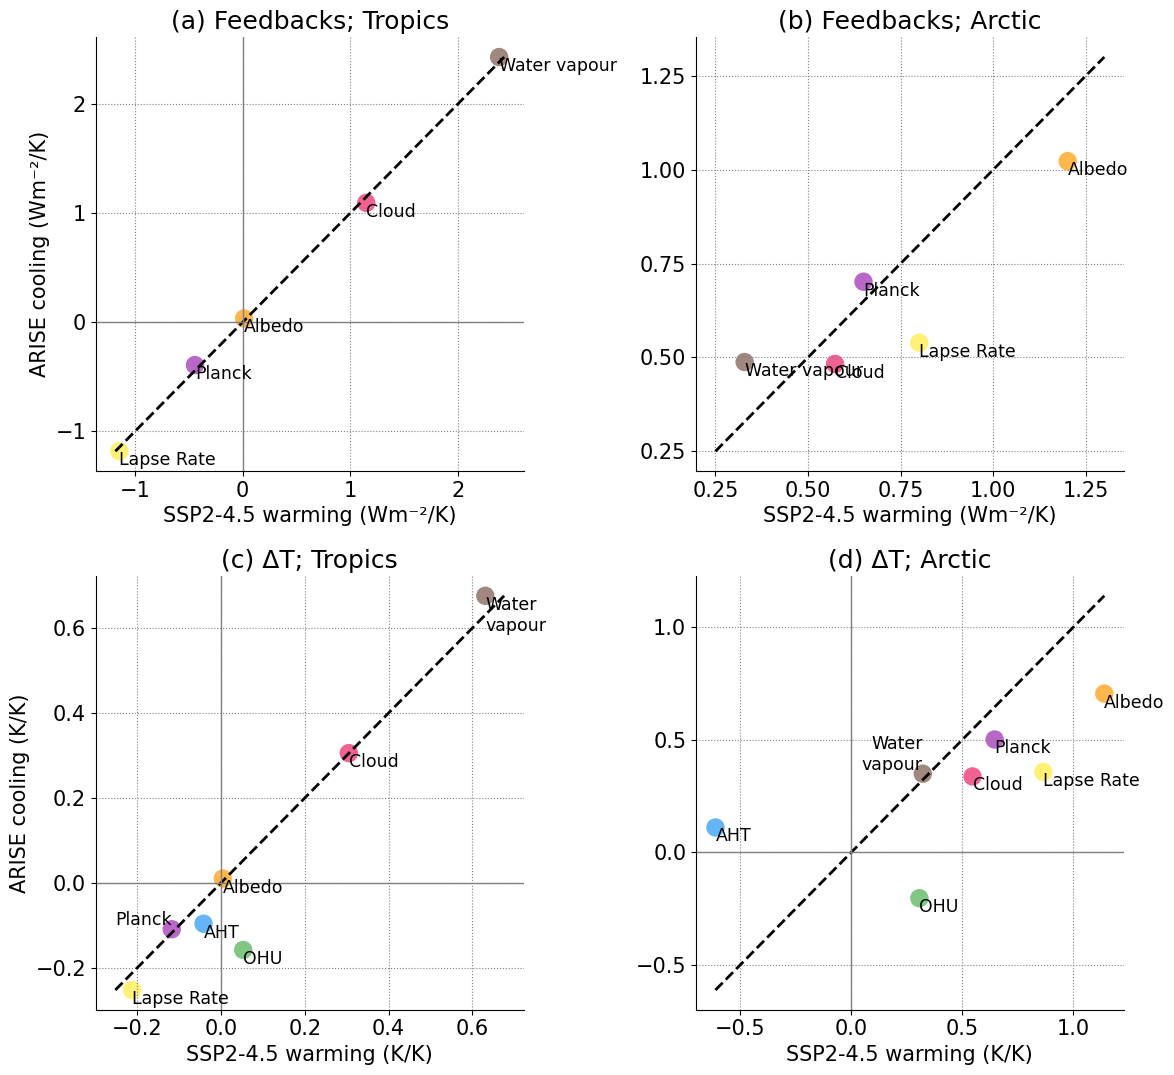

In [46]:
### and repeat with the 2nd format

### repeat the above plot but normalised by the LOCAL temp change 

## also combine all the scatters into one: 

## plot the arctic vs tropical warming contributions under ssp and sai


### now plot for both regions:

fig, axs = plt.subplots(2, 2, figsize = (12, 11))



l=0
titles = ['(a) Feedbacks; Tropics', '(b) Feedbacks; Arctic']
for region in ['Tropics', 'Arctic']:
    ax = axs[0, l]
 

    fs, fs_A, fs_T, labs = [], [], [], []
    for f in ['LR', 'Planck_dash', 'WV', 'Alb']:
        lambda_f_sai = Rs_dict['sai'][region].mean('time')[f].values/Rs_dict['sai'][region].mean('time')['delta_TS'].values
        lambda_f_ssp = Rs_dict['ssp'][region].mean('time')[f].values/Rs_dict['ssp'][region].mean('time')['delta_TS'].values
        fs.append(lambda_f_sai)
        fs.append(lambda_f_ssp)
        fs.append(lambda_f_sai)
        fs_A.append(lambda_f_sai)
        fs.append(lambda_f_ssp)
        fs_T.append(lambda_f_ssp)
        labs.append(f)

    lambda_cloud_sai = cloudR_dict['sai'][region].mean('time').values/Rs_dict['sai'][region].mean('time')['delta_TS'].values
    lambda_cloud_ssp = cloudR_dict['ssp'][region].mean('time').values/Rs_dict['ssp'][region].mean('time')['delta_TS'].values
    labs.append('Cloud')
    fs_A.append(lambda_cloud_sai)
    fs_T.append(lambda_cloud_ssp)

    ax.scatter(fs_T, fs_A, s=150, c=[color_scheme[x] for x in labs])
    for i, txt in enumerate(labs):
        ax.annotate(process_labels[txt], (fs_T[i], fs_A[i]), va='top', ha='left', fontsize='small')
        
    #if l == 0:
    line = [np.min(fs), np.max(fs)]
    if l ==1:
        line = [0.25, 1.3]
        ax.set_xticks(np.arange(0.25, 1.3, 0.25))
        ax.set_yticks(np.arange(0.25, 1.3, 0.25))
            
    ax.plot(line, line, c='black', linewidth=2, linestyle='--')
    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    ax.grid(ls='dotted', c='gray')
    if l == 0:
        ax.axhline(0, c='gray', linewidth=1)
        ax.axvline(0, c='gray', linewidth=1)
        ax.set_xticks(np.arange(-1, 2.2, 1))
        ax.set_yticks(np.arange(-1, 2.2, 1))
       
    if l ==0:
        ax.set_ylabel('ARISE cooling (Wm\u207B\u00B2/K)'.format(r=region), fontsize='medium')
    ax.set_xlabel('SSP2-4.5 warming (Wm\u207B\u00B2/K)'.format(r=region), fontsize='medium')
    ax.set_title(titles[l])
    l=l+1

l=0
titles = ['(c) ΔT; Tropics', '(d) ΔT; Arctic']
for region in ['Tropics', 'Arctic']:
    ax = axs[1, l]
    
    df_x = pd.DataFrame(get_delta_T_contribs_dict('ssp', region)).mean()
    df_y = pd.DataFrame(get_delta_T_contribs_dict('sai', region)).mean().drop('F')
    
    df_x = df_x/QACC_utils.calc_spatial_mean(Rs_dict['ssp']['Spatial'].delta_TS, 'lon', 'lat').mean().item()
    df_y = df_y/QACC_utils.calc_spatial_mean(Rs_dict['sai']['Spatial'].delta_TS, 'lon', 'lat').mean().item()

    #if l == 0:
    line = [np.min([np.min(df_x), np.min(df_y)]), np.max([np.max(df_x), np.max(df_y)])]
    
    ax.plot(line, line, c='black', linewidth=2, linestyle='--')
    
    ax.scatter(df_x, df_y, s=150, c=[color_scheme[x] for x in df_x.keys()])

    for i, txt in enumerate(df_x.keys()):
        if txt == 'Planck':
            if l == 0:
                va, ha = 'bottom', 'right'
        elif txt == 'WV':
            if l == 1:
                va, ha = 'bottom', 'right'
        else:
            va, ha = 'top', 'left'
        ax.annotate(process_labels2[txt], (list(df_x)[i], list(df_y)[i]), va=va, ha=ha, fontsize='small')    
    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_title('')
    ax.grid(ls='dotted', c='gray')
    ax.axhline(0, c='gray', linewidth=1)
    ax.axvline(0, c='gray', linewidth=1)
    if l==1:
        ax.set_xticks(np.arange(-0.5, 1.3, 0.5))
        ax.set_yticks(np.arange(-0.5, 1.3, 0.5))
    if l ==0:
        ax.set_ylabel('ARISE cooling (K/K)'.format(r=region), fontsize='medium')
    ax.set_xlabel('SSP2-4.5 warming (K/K)'.format(r=region), fontsize='medium')
    ax.set_title(titles[l])
    l=l+1
plt.tight_layout()   
plt.savefig('figures/relative_all_feedbacks_and_deltaTs.jpg', dpi=300, bbox_inches='tight')

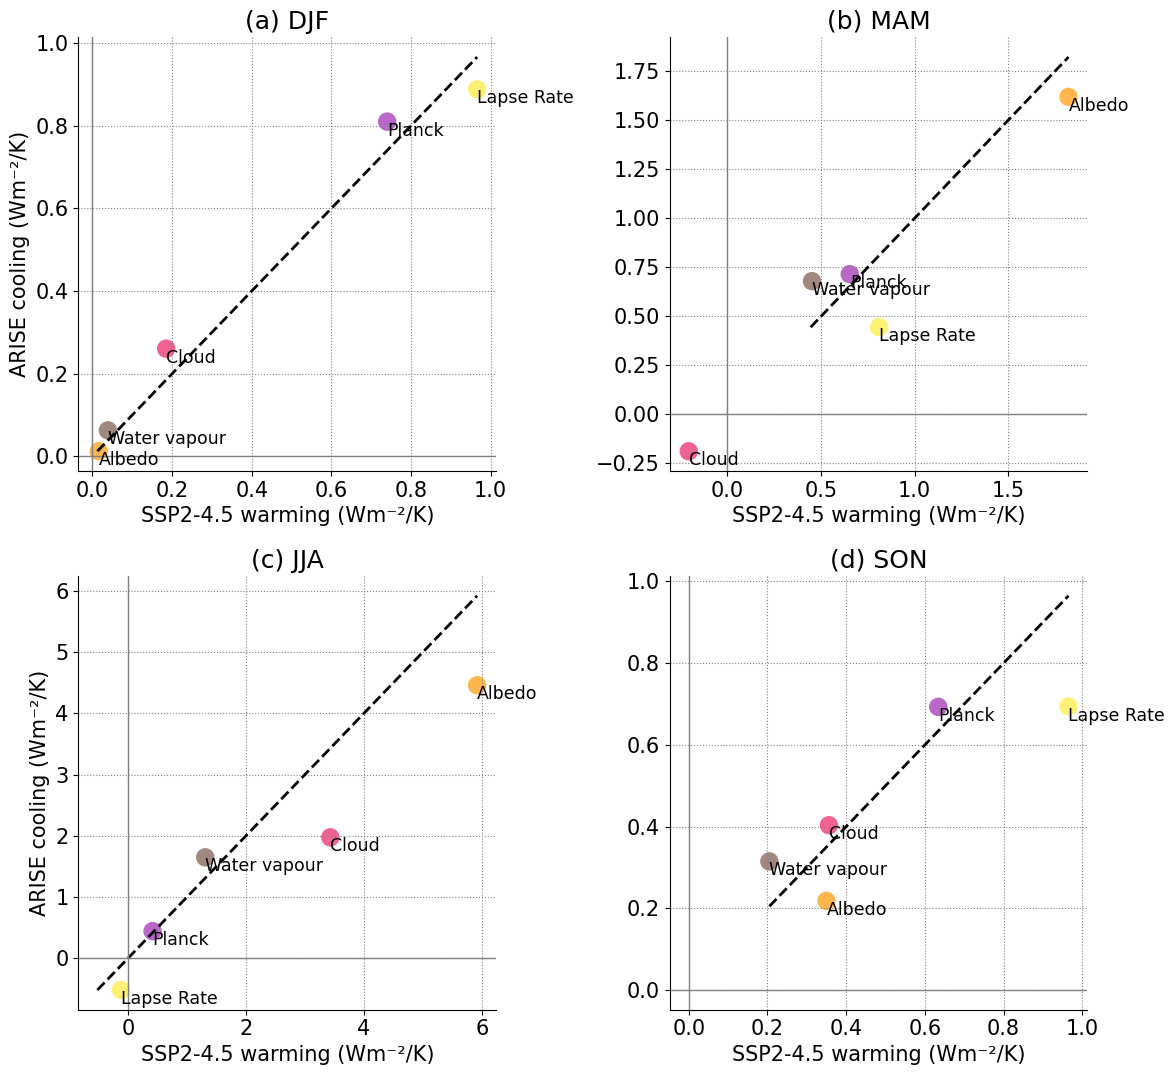

In [47]:
## repeat top right and bottom right of the one above, with the seasonal breakdown: 

### and repeat with the 2nd format

### repeat the above plot but normalised by the LOCAL temp change 

## also combine all the scatters into one: 

## plot the arctic vs tropical warming contributions under ssp and sai


### now plot for both regions:

fig, axs = plt.subplots(2, 2, figsize = (12, 11))


titles = ['(a) DJF', '(b) MAM', 
          '(c) JJA', '(d) SON']
monthss = [[0,1,11], [2, 3, 4], [5, 6, 7], [8, 9, 10]]
region = 'Arctic'

for l in range(4):
    ax = axs.flatten()[l]
    months = monthss[l]

    fs, fs_A, fs_T, labs = [], [], [], []
    for f in ['LR', 'Planck_dash', 'WV', 'Alb']:
        lambda_f_sai = Rs_dict['sai']['Arctic'].isel(time=months).mean('time')[f].values/Rs_dict['sai']['Arctic'].isel(time=months).mean('time')['delta_TS'].values
        lambda_f_ssp = Rs_dict['ssp']['Arctic'].isel(time=months).mean('time')[f].values/Rs_dict['ssp']['Arctic'].isel(time=months).mean('time')['delta_TS'].values
        fs.append(lambda_f_sai)
        fs.append(lambda_f_ssp)
        fs.append(lambda_f_sai)
        fs_A.append(lambda_f_sai)
        fs.append(lambda_f_ssp)
        fs_T.append(lambda_f_ssp)
        labs.append(f)

    lambda_cloud_sai = cloudR_dict['sai']['Arctic'].isel(time=months).mean('time').values/Rs_dict['sai']['Arctic'].isel(time=months).mean('time')['delta_TS'].values
    lambda_cloud_ssp = cloudR_dict['ssp']['Arctic'].isel(time=months).mean('time').values/Rs_dict['ssp']['Arctic'].isel(time=months).mean('time')['delta_TS'].values
    labs.append('Cloud')
    fs_A.append(lambda_cloud_sai)
    fs_T.append(lambda_cloud_ssp)

    ax.scatter(fs_T, fs_A, s=150, c=[color_scheme[x] for x in labs])
    for i, txt in enumerate(labs):
        ax.annotate(process_labels[txt], (fs_T[i], fs_A[i]), va='top', ha='left', fontsize='small')
        
    #if l == 0:
    line = [np.min(fs), np.max(fs)]
            
    ax.plot(line, line, c='black', linewidth=2, linestyle='--')
    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    ax.grid(ls='dotted', c='gray')
    ax.axhline(0, c='gray', linewidth=1)
    ax.axvline(0, c='gray', linewidth=1)
       
    if l in [0, 2]:
        ax.set_ylabel('ARISE cooling (Wm\u207B\u00B2/K)'.format(r=region), fontsize='medium')
    ax.set_xlabel('SSP2-4.5 warming (Wm\u207B\u00B2/K)'.format(r=region), fontsize='medium')
    ax.set_title(titles[l])
    l=l+1


plt.tight_layout()   
plt.savefig('figures/Arctic_feedbacks_seasonal.jpg', dpi=300, bbox_inches='tight')

In [48]:
### now add some maps:

## need to read in the spatial forcing and CRE (because i didn't save it spatially before):

rad_flux_vars_TOA = ['rsdt', 'rsut', 'rlut', 'rlutcs', 'rsutcs', 'rsutaf', 'rsutcsaf']
rad_flux_vars_surf = ['rsds', 'rsus', 'rlds', 'rlus', 'hfls', 'hfss']

def get_F_CRE(ds):
    # add OHU
    ds['OHU'] = ds.rsds - ds.rsus + ds.rlds - ds.rlus - ds.hfls - ds.hfss
    ## adds F, albedo, and CRE, and saves:
    # add IRF, allsky and clearsky
    ds['IRF_aer'] = ds['rsutaf'] - ds['rsut']  # sign convention here is that more SW to space is a negative forcing
    ds['IRF_aer_cs'] = ds['rsutcsaf'] - ds['rsutcs']
    # add CRE (cloud radiative effect))
    ds['CRE'] = ((ds['rsutcs']-ds['rsut'])+(ds['rlutcs']-ds['rlut']))
    return ds

ds_F_ssp245 = get_F_CRE(QACC_utils.get_all_vars_spatial_monthly(vars=rad_flux_vars_TOA+rad_flux_vars_surf, model=model, scenario='ssp245',
                                                    min_year=time_slice_dict['ssp245'][0],
                                                    max_year=time_slice_dict['ssp245'][1]))

ds_F_ssp245_baseline = get_F_CRE(QACC_utils.get_all_vars_spatial_monthly(vars=rad_flux_vars_TOA+rad_flux_vars_surf, model=model, scenario='ssp245',
                                                    min_year=time_slice_dict['ssp245_baseline'][0],
                                                    max_year=time_slice_dict['ssp245_baseline'][1]))

ds_F_arise = get_F_CRE(QACC_utils.get_all_vars_spatial_monthly(vars=rad_flux_vars_TOA+rad_flux_vars_surf, model=model, scenario='ARISE',
                                                   min_year=time_slice_dict['ARISE'][0],
                                                   max_year=time_slice_dict['ARISE'][1]))

  0%|          | 0/13 [00:00<?, ?it/s]

rsdt


  8%|▊         | 1/13 [00:02<00:24,  2.05s/it]

rsut


 15%|█▌        | 2/13 [00:04<00:22,  2.02s/it]

...

 85%|████████▍ | 11/13 [00:06<00:01,  1.88it/s]

hfls


 92%|█████████▏| 12/13 [00:06<00:00,  1.76it/s]

hfss


100%|██████████| 13/13 [00:08<00:00,  1.59it/s]


In [49]:

ds_F_sai = (ds_F_arise - ds_F_ssp245).rename({'x':'lon', 'y':'lat', 'month':'time'})
feedback_masking = sum([(Rs_dict['sai']['Spatial'][str(feedback+'_cs')] - Rs_dict['sai']['Spatial'][feedback]) for feedback in all_feedbacks])
IRF_masking = 1*(ds_F_sai['IRF_aer_cs'] - ds_F_sai['IRF_aer'])
cloud_R_sai = (ds_F_sai['CRE'] + IRF_masking + feedback_masking).load()

ds_F_ssp = (ds_F_ssp245 - ds_F_ssp245_baseline).rename({'x':'lon', 'y':'lat', 'month':'time'})
feedback_masking = sum([(Rs_dict['ssp']['Spatial'][str(feedback+'_cs')] - Rs_dict['ssp']['Spatial'][feedback]) for feedback in all_feedbacks])
IRF_masking = 1*(ds_F_ssp['IRF_aer_cs'] - ds_F_ssp['IRF_aer'])
cloud_R_ssp = (ds_F_ssp['CRE'] + IRF_masking + feedback_masking).load()

cloud_Rs_dict = {'sai':cloud_R_sai, 'ssp':cloud_R_ssp}

In [50]:
ds_F_sai

<xarray.Dataset> Size: 23MB
Dimensions:                 (lat: 144, lon: 192, time: 12, bnds: 2)
Coordinates:
  * lat                     (lat) float64 1kB -89.38 -88.12 ... 88.12 89.38
  * lon                     (lon) float64 2kB 0.9375 2.812 4.688 ... 357.2 359.1
  * time                    (time) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: bnds
Data variables: (12/20)
    lat_bounds              (time, lat, bnds) float64 28kB dask.array<chunksize=(1, 144, 2), meta=np.ndarray>
    lon_bounds              (time, lon, bnds) float64 37kB dask.array<chunksize=(1, 192, 2), meta=np.ndarray>
    rsdt                    (time, lat, lon) float32 1MB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
    number_ens_mems_meaned  (time) float64 96B -10.0 -10.0 -10.0 ... -10.0 -10.0
    rsut                    (time, lat, lon) float32 1MB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
    rlut                    (time, lat, lon) float32 1MB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
    ...                      ...
    hfls                    (time, lat, lon) float32 1MB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
    hfss                    (time, lat, lon) float32 1MB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
    OHU                     (time, lat, lon) float32 1MB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
    IRF_aer                 (time, lat, lon) float32 1MB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
    IRF_aer_cs              (time, lat, lon) float32 1MB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>
    CRE                     (time, lat, lon) float32 1MB dask.array<chunksize=(1, 144, 192), meta=np.ndarray>

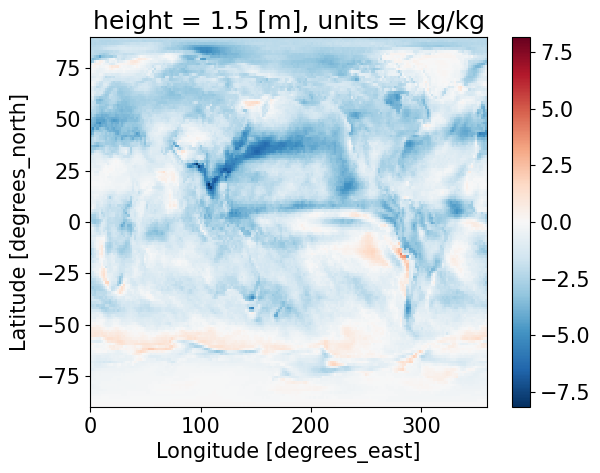

In [51]:
cloud_R_sai.mean('time').plot()

In [55]:
"""
### combine this cloud_R_x with the lambdas calculated way above, to plot spatial feedbacks
import numpy as np
import string
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

## units of (W/m2/K) 
## lambda_i = R_i/delta_TS

lambda_cloud_sai, lambda_cloud_ssp = cloud_R_sai/Rs_dict['sai']['Spatial']['delta_TS'], cloud_R_ssp/Rs_dict['ssp']['Spatial']['delta_TS']
delta_lambda_cloud = lambda_cloud_sai - lambda_cloud_ssp



### plot as 3 columns (Annual mean, summer, winter), and 5 rows (for Planck, Cloud, Lapse Rate, Albedo, Water Vapour)



fig, axes = plt.subplots(5, 3, figsize=(7, 10), subplot_kw={'projection': ccrs.NorthPolarStereo()})

extent = [-180, 180, 50, 90] 

month_dict = {'Annual mean':[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
              'DJF': [12, 1, 2],
              'MAM': [3, 4, 5],
              'JJA': [6, 7, 8],
              'SON': [9, 10, 11]}

j=0

for season in ['Annual mean', 'JJA', 'DJF']:

    
    i=0
    #levels = np.arange(-5, 5.2, 0.5)
    #subtitle_labs = ['(c)', '(d)', '(e)', '(f)', '(g)', '(h)', '(i)']
    for feedback in ['Planck', 'Alb', 'LR', 'WV']:
        data = delta_lambdas[feedback]
        data = data.sel(lat=slice(30, 90))
        data = data.where(data.time.isin(month_dict[season]), drop=True).mean('time')
        cyclic_data, cyclic_lons = add_cyclic_point(data.values, coord=data['lon'])
        ax = axes[i, j]
        cont = ax.contourf(cyclic_lons, data['lat'], cyclic_data,
                           transform=ccrs.PlateCarree(),
                           levels=levels,
                           cmap='bwr',
                           extend='both')
        ax.set_title(str(subtitle_labs[j]+process_labels[feedback]))
        #j=j+1
        i=i+1

    data = delta_lambda_cloud
    data = data.sel(lat=slice(30, 90))
    data = data.where(data.time.isin(month_dict[season]), drop=True).mean('time')
    cyclic_data, cyclic_lons = add_cyclic_point(data.values, coord=data['lon'])
    ax = axes[i, j]
    cont = ax.contourf(cyclic_lons, data['lat'], cyclic_data,
                       transform=ccrs.PlateCarree(),
                       levels=levels,
                       cmap='bwr',
                       extend='both')
    ax.set_title(str(subtitle_labs[j]+' Cloud'))
    j=j+1
    i=i+1
    
    
for ax in axes.flatten():
    ax.set_extent(extent, ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, color='black')
    ax.gridlines(draw_labels=False, dms=True, xlocs=np.arange(-180, 181, 45), ylocs=np.arange(0, 91, 30), color='lightgray', linestyle='--')

cbar_ax = fig.add_axes([0.2, -0.05, 0.6, 0.04])  # [left, bottom, width, height]
cbar = fig.colorbar(cont, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Wm$^{-2}$/K')


fig.suptitle('ARISE-SAI-1.5 - SSP2-4.5', fontsize='large')
plt.tight_layout()
#plt.savefig('figures/Spatial_maps_of_SAI_contributions_{s}.jpg'.format(s=season), dpi=300, bbox_inches='tight', pad_inches=0.2)

"""

"\n### combine this cloud_R_x with the lambdas calculated way above, to plot spatial feedbacks\nimport numpy as np\nimport string\nimport matplotlib.pyplot as plt\nimport matplotlib.patheffects as pe\nimport cartopy.crs as ccrs\nimport cartopy.feature as cfeature\nfrom cartopy.util import add_cyclic_point\n\n## units of (W/m2/K) \n## lambda_i = R_i/delta_TS\n\nlambda_cloud_sai, lambda_cloud_ssp = cloud_R_sai/Rs_dict['sai']['Spatial']['delta_TS'], cloud_R_ssp/Rs_dict['ssp']['Spatial']['delta_TS']\ndelta_lambda_cloud = lambda_cloud_sai - lambda_cloud_ssp\n\n\n\n### plot as 3 columns (Annual mean, summer, winter), and 5 rows (for Planck, Cloud, Lapse Rate, Albedo, Water Vapour)\n\n\n\nfig, axes = plt.subplots(5, 3, figsize=(7, 10), subplot_kw={'projection': ccrs.NorthPolarStereo()})\n\nextent = [-180, 180, 50, 90] \n\nmonth_dict = {'Annual mean':[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],\n              'DJF': [12, 1, 2],\n              'MAM': [3, 4, 5],\n              'JJA': [6, 7, 8],\n   

/home/users/a_duffey/.conda/envs/main2/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/users/a_duffey/.conda/envs/main2/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/users/a_duffey/.conda/envs/main2/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/users/a_duffey/.conda/envs/main2/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/users/a_duffey

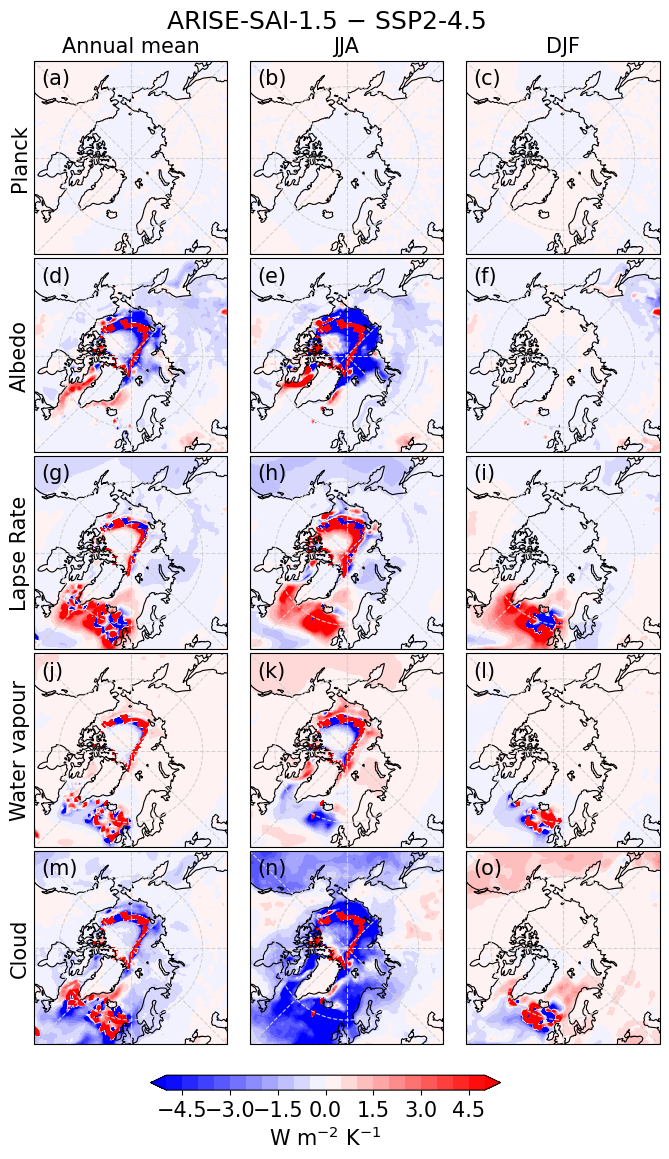

In [54]:
import numpy as np
import string
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

### combine cloud_R_x with the lambdas calculated above, to plot spatial feedbacks
### units of W m-2 K-1; lambda_i = R_i / delta_TS
lambda_cloud_sai = cloud_R_sai / Rs_dict['sai']['Spatial']['delta_TS']
lambda_cloud_ssp = cloud_R_ssp / Rs_dict['ssp']['Spatial']['delta_TS']
delta_lambda_cloud = lambda_cloud_sai - lambda_cloud_ssp

month_dict = {'Annual mean': list(range(1, 13)),
              'JJA': [6, 7, 8],
              'DJF': [12, 1, 2]}

# rows = feedbacks, columns = seasons
feedbacks = ['Planck', 'Alb', 'LR', 'WV', 'Cloud']
seasons = ['Annual mean', 'JJA', 'DJF']

fields = {fb: delta_lambdas[fb] for fb in feedbacks[:-1]}
fields['Cloud'] = delta_lambda_cloud
row_labels = {**process_labels, 'Cloud': 'Cloud'}

def seasonal_mean(da, season):
    da = da.sel(lat=slice(30, 90))
    return da.where(da.time.isin(month_dict[season]), drop=True).mean('time')

# ---- common levels for every panel ----
# Option A: fixed, symmetric about zero
levels = np.arange(-5, 5.5, 0.5)
# Option B: derive from the data so nothing saturates unnecessarily
# vmax = max(float(abs(seasonal_mean(fields[fb], s)).max())
#            for fb in feedbacks for s in seasons)
# levels = np.linspace(-vmax, vmax, 21)

fig, axes = plt.subplots(len(feedbacks), len(seasons),
                         figsize=(7, 11.5),
                         subplot_kw={'projection': ccrs.NorthPolarStereo()})

for i, fb in enumerate(feedbacks):
    for j, season in enumerate(seasons):
        ax = axes[i, j]
        data = seasonal_mean(fields[fb], season)
        cyclic_data, cyclic_lons = add_cyclic_point(data.values, coord=data['lon'])
        cont = ax.contourf(cyclic_lons, data['lat'], cyclic_data,
                           transform=ccrs.PlateCarree(),
                           levels=levels, cmap='bwr', extend='both')
        ax.set_extent([-180, 180, 50, 90], ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8, color='black')
        ax.gridlines(draw_labels=False, dms=True,
                     xlocs=np.arange(-180, 181, 45),
                     ylocs=np.arange(0, 91, 30),
                     color='lightgray', linestyle='--')

        # (a), (b), ... in white, top-left, reading order
        label = string.ascii_lowercase[i * len(seasons) + j]
        ax.text(0.04, 0.96, f'({label})', transform=ax.transAxes,
                ha='left', va='top', color='black',
                fontsize='medium', zorder=10)
                #path_effects=[pe.withStroke(linewidth=1.5, foreground='0.3')])

        if i == 0:  # column headers = seasons
            ax.set_title(season, fontsize='medium')
        if j == 0:  # row labels = feedbacks
            ax.text(-0.07, 0.5, row_labels[fb], transform=ax.transAxes,
                    rotation=90, ha='center', va='center', fontsize='medium')

# manual spacing instead of tight_layout (which fights cartopy's fixed aspect)
fig.subplots_adjust(left=0.07, right=0.99, top=0.93, bottom=0.075,
                    wspace=0.02, hspace=0.02)

cbar_ax = fig.add_axes([0.25, 0.035, 0.5, 0.013])
cbar = fig.colorbar(cont, cax=cbar_ax, orientation='horizontal')
cbar.set_label(r'W m$^{-2}$ K$^{-1}$')

fig.suptitle('ARISE-SAI-1.5 $-$ SSP2-4.5', fontsize='large', y=0.975)

plt.savefig('figures/Spatial_maps_of_feedbacks_SAI_minus_ARISE.jpg', dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

In [56]:
Rs_dict[scen]['Arctic']

<xarray.Dataset> Size: 2kB
Dimensions:                    (time: 12)
Coordinates:
  * time                       (time) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    height                     float64 8B ...
    units                      <U5 20B ...
Data variables: (12/16)
    LR                         (time) float64 96B -4.663 -3.369 ... -6.272
    Planck                     (time) float64 96B 12.23 9.63 ... 16.59 16.21
    WV                         (time) float64 96B -0.2853 -0.3899 ... -0.3404
    Alb                        (time) float64 96B -0.01005 ... -9.017e-05
    LR_cs                      (time) float64 96B -3.607 -2.587 ... -4.958
    Planck_cs                  (time) float64 96B 12.86 10.16 ... 17.7 17.12
    ...                         ...
    q_strat                    (time) float64 96B -0.02312 -0.04868 ... -0.03911
    q_strat_cs                 (time) float64 96B -0.02474 -0.05062 ... -0.04083
    delta_TS                   (time) float64 96B -5.191 -4.106 ... -6.814
    Planck_dash                (time) float64 96B -4.19 -3.52 ... -4.949 -5.336
    Planck_dash_cs             (time) float64 96B -4.935 -4.111 ... -6.233
    Planck_global_mean_lambda  (time) float64 96B -3.162 -3.203 ... -3.162

In [59]:
ds_F_sai['IRF_aer'].sel(time=slice(6, 8), drop=True)

<xarray.DataArray 'IRF_aer' (time: 3, lat: 144, lon: 192)> Size: 332kB
dask.array<getitem, shape=(3, 144, 192), dtype=float32, chunksize=(1, 144, 192), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 1kB -89.38 -88.12 -86.88 -85.62 ... 86.88 88.12 89.38
  * lon      (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
  * time     (time) int64 24B 6 7 8

In [ ]:
def get_delta_T_contribs_spatial_dict(scen):
    
    Rs = Rs_dict[scen]['Spatial']
    ds_delta_sm = ds_F_sai if scen == 'sai' else ds_F_ssp
    Planck_global_mean_lambda = Rs_dict[scen]['Arctic']['Planck_global_mean_lambda']
    cloud_R = cloud_Rs_dict[scen]

    delta_T_contribs = {
        'F':-ds_delta_sm['IRF_aer']/Planck_global_mean_lambda
        #'AHT':-ds_delta_sm['AHT']/Planck_global_mean_lambda,
        'OHU':ds_delta_sm['OHU']/Planck_global_mean_lambda, # our OHU is defined the 'wrong' way round, positive into the ocean
        'Planck':-Rs['Planck_dash']/Planck_global_mean_lambda,
        'Alb':-Rs['Alb']/Planck_global_mean_lambda,
        'LR':-(Rs['LR']+Rs['T_strat'])/Planck_global_mean_lambda, # include strat T changes in LR (pretty small but not negligible, larger in Arctic winter)
        'WV':-(Rs['WV']+Rs['q_strat'])/Planck_global_mean_lambda, # include strat q changes in WV (negligible in all months)
        #'T_strat':-Rs['T_strat']/Planck_global_mean_lambda,
        #'q_strat':-Rs['q_strat']/Planck_global_mean_lambda,
        'Cloud':-cloud_R/Planck_global_mean_lambda}
    
    if scen == 'ssp':
        del delta_T_contribs['F'] # F is the aerosol forcing, not meaningful for ssp warming
        
    return delta_T_contribs

In [ ]:
sai_spatial = get_delta_T_contribs_spatial_dict('sai')

In [ ]:
## also get the feedback strengths themselves (W/m2/K) 
## lambda_i = R_i/delta_TS

## 

In [ ]:
sai_spatial['LR']

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point

In [ ]:
### sea ice

ens_mems_arise_UK = ['r1i1p1f2', 'r2i1p1f2', 'r3i1p1f2', 'r4i1p1f2', 'r8i1p1f2']

DS_ssp245_SI_UK = get_ds_from_ceda(model='UKESM1-0-LL', centre='MOHC', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='siconca', members=ens_mems_arise_UK, 
                              table='SImon', grid='gr').sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'}).load()
DS_ssp245_SI_UK = DS_ssp245_SI_UK.sel(time=slice(time_slice_dict['ssp245'][0], time_slice_dict['ssp245'][1])).mean('Ensemble_member')

### get siconca for ARISE
paths_si = glob.glob('/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/*/SImon/siconca/gr/*/')
ds_list_si = []
for path in paths_si:
    #files = os.listdir(path)
    ds = rename_cmip6(xr.open_mfdataset(path+'*.nc')).sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'})
    ds_list_si.append(ds)
DS_ARISE_siconca = xr.concat(ds_list_si, dim='Ensemble_member').sel(time=slice(time_slice_dict['ARISE'][0], time_slice_dict['ARISE'][1])).mean('Ensemble_member').load()

DS_ARISE_siconca = DS_ARISE_siconca.groupby(DS_ARISE_siconca.time.dt.month).mean()
DS_ssp245_SI_UK = DS_ssp245_SI_UK.groupby(DS_ssp245_SI_UK.time.dt.month).mean()

In [ ]:

delta_siconca = DS_ARISE_siconca['siconca'] - DS_ssp245_SI_UK['siconca']

In [ ]:
Rs_dict[scen]['Spatial']['delta_TS']

In [ ]:

fig, axes = plt.subplots(3, 3, figsize=(7, 10), subplot_kw={'projection': ccrs.NorthPolarStereo()})

extent = [-180, 180, 50, 90] 

month_dict = {'Annual mean':[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
              'DJF': [12, 1, 2],
              'MAM': [3, 4, 5],
              'JJA': [6, 7, 8],
              'SON': [9, 10, 11]}

season = 'JJA'

T_levs = {'DJF':np.arange(-10, -1, 1),
          'Annual mean':np.arange(-3, -1, 0.25),
          'JJA':np.arange(-3.5, 0, 0.5),}

i = 0
data = Rs_dict[scen]['Spatial']['delta_TS']
data = data.where(data.time.isin(month_dict[season]), drop=True).mean('time')
data = data.sel(lat=slice(30, 90))
cyclic_data, cyclic_lons = add_cyclic_point(data.values, coord=data['lon'])
ax = axes.flatten()[i]
cont_T = ax.contourf(cyclic_lons, data['lat'], cyclic_data,
                    transform=ccrs.PlateCarree(),
                    levels=T_levs[season],
                    cmap='YlGnBu_r',
                    extend='both')
ax.set_title('(a) Temperature')
i=i+1


data = delta_siconca.where(delta_siconca.month.isin(month_dict[season]), drop=True).mean('month')
cyclic_data, cyclic_lons = add_cyclic_point(data.values, coord=data['longitude'])
ax = axes.flatten()[i]
cont_SI = ax.contourf(cyclic_lons, data['latitude'], cyclic_data,
                    transform=ccrs.PlateCarree(),
                    levels=np.arange(0, 40, 5),
                    cmap='Blues_r',
                    extend='both')
ax.set_title('(b) Sea ice conc.')
i=i+1

j=0
levels = np.arange(-5, 5.2, 0.5)
subtitle_labs = ['(c)', '(d)', '(e)', '(f)', '(g)', '(h)', '(i)']
for feedback in ['F', 'Planck', 'Alb', 'LR', 'WV', 'Cloud', 'OHU']:
    data = sai_spatial[feedback]
    data = data.where(data.time.isin(month_dict[season]), drop=True).mean('time')
    cyclic_data, cyclic_lons = add_cyclic_point(data.values, coord=data['lon'])
    ax = axes.flatten()[i]
    cont = ax.contourf(cyclic_lons, data['lat'], cyclic_data,
                       transform=ccrs.PlateCarree(),
                       levels=levels,
                       cmap='bwr',
                       extend='both')
    ax.set_title(str(subtitle_labs[j]+process_labels[feedback]))
    j=j+1
    i=i+1

for ax in axes.flatten():
    ax.set_extent(extent, ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, color='black')
    ax.gridlines(draw_labels=False, dms=True, xlocs=np.arange(-180, 181, 45), ylocs=np.arange(0, 91, 30), color='lightgray', linestyle='--')

cbar_ax2 = fig.add_axes([1, 0.7, 0.025, 0.2])  # [left, bottom, width, height]
cbar2 = fig.colorbar(cont_T, cax=cbar_ax2, orientation='vertical')
cbar2.set_label('K')

# plus one more for sea ice
cbar_ax3 = fig.add_axes([1, 0.45, 0.025, 0.2])  # [left, bottom, width, height]
cbar3 = fig.colorbar(cont_SI, cax=cbar_ax3, orientation='vertical')
cbar3.set_label('Δ%')

    
cbar_ax = fig.add_axes([0.2, -0.05, 0.6, 0.04])  # [left, bottom, width, height]
cbar = fig.colorbar(cont, cax=cbar_ax, orientation='horizontal')
cbar.set_label('K')


fig.suptitle('ARISE-SAI-1.5 - SSP2-4.5 ({s})'.format(s=season), fontsize='large')
plt.tight_layout()
plt.savefig('figures/Spatial_maps_of_SAI_contributions_{s}.jpg'.format(s=season), dpi=300, bbox_inches='tight', pad_inches=0.2)

In [ ]:
### also plot the cloudiness timeseries and maps: 

#os.listdir('/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/r1i1p1f2/Amon/')

### cloud cover
DS_ssp245_clt = get_ds_from_ceda(model='UKESM1-0-LL', centre='MOHC', scenario_group = 'ScenarioMIP',
                              scenario = 'ssp245', variable='clt', members=ens_mems_arise_UK, 
                              table='Amon', grid='gn').sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'}).load()

paths_clt = glob.glob('/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/*/Amon/clt/gn/*/')
ds_list_clt = []
for path in paths_clt:
    #files = os.listdir(path)
    ds = rename_cmip6(xr.open_mfdataset(path+'*.nc')).sel(time=slice('2015', '2069')).rename({'y':'latitude', 'x':'longitude'})
    ds_list_clt.append(ds)
DS_ARISE_clt = xr.concat(ds_list_clt, dim='Ensemble_member').load()

DS_ssp245_clt_am = DS_ssp245_clt.groupby('time.year').mean('time')
DS_ARISE_clt_am = DS_ARISE_clt.groupby('time.year').mean('time')

DS_ssp245_clt_DJF = DS_ssp245_clt.where(DS_ssp245_clt.time.dt.month.isin([12, 1, 2]), drop=True).groupby('time.year').mean('time')
DS_ssp245_clt_JJA = DS_ssp245_clt.where(DS_ssp245_clt.time.dt.month.isin([6, 7, 8]), drop=True).groupby('time.year').mean('time')

DS_ARISE_clt_DJF = DS_ARISE_clt.where(DS_ARISE_clt.time.dt.month.isin([12, 1, 2]), drop=True).groupby('time.year').mean('time')
DS_ARISE_clt_JJA = DS_ARISE_clt.where(DS_ARISE_clt.time.dt.month.isin([6, 7, 8]), drop=True).groupby('time.year').mean('time')


ssp245_clt_am_timeseries_dict = dict(zip(regions, [spatial_mean(DS_ssp245_clt_am.rename({'latitude':'y', 'longitude':'x'}), region, lat_band_dict=lat_band_dict) for region in regions]))
arise_clt_am_timeseries_dict = dict(zip(regions, [spatial_mean(DS_ARISE_clt_am.rename({'latitude':'y', 'longitude':'x'}), region, lat_band_dict=lat_band_dict) for region in regions]))

ssp245_clt_DJF_timeseries_dict = dict(zip(regions, [spatial_mean(DS_ssp245_clt_DJF.rename({'latitude':'y', 'longitude':'x'}), region, lat_band_dict=lat_band_dict) for region in regions]))
arise_clt_DJF_timeseries_dict = dict(zip(regions, [spatial_mean(DS_ARISE_clt_DJF.rename({'latitude':'y', 'longitude':'x'}), region, lat_band_dict=lat_band_dict) for region in regions]))

ssp245_clt_JJA_timeseries_dict = dict(zip(regions, [spatial_mean(DS_ssp245_clt_JJA.rename({'latitude':'y', 'longitude':'x'}), region, lat_band_dict=lat_band_dict) for region in regions]))
arise_clt_JJA_timeseries_dict = dict(zip(regions, [spatial_mean(DS_ARISE_clt_JJA.rename({'latitude':'y', 'longitude':'x'}), region, lat_band_dict=lat_band_dict) for region in regions]))

ssp245_clt_timeseries_dict = {'Annual mean':ssp245_clt_am_timeseries_dict,
                                'DJF':ssp245_clt_DJF_timeseries_dict,
                                'JJA':ssp245_clt_JJA_timeseries_dict}
arise_clt_timeseries_dict = {'Annual mean':arise_clt_am_timeseries_dict,
                                'DJF':arise_clt_DJF_timeseries_dict,
                                'JJA':arise_clt_JJA_timeseries_dict}

In [ ]:
fig, axs = plt.subplots(3, 2, figsize = (12, 10), sharey=False, sharex=True)
colours = {'ssp245':'gray',
           'ssp245_light':'lightgray',}


labs = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
k=0
i=0
for season in ['Annual mean', 'JJA', 'DJF']:
    j=0
    for region in ['Tropics', 'Arctic']:
        #ax = axs[0] if region == 'Tropics' else axs[1]
        ax = axs[i, j]
        ax.set_title('{l} {r}; {s}'.format(l=labs[k], r=region, s=season))
        
        

        # do for ssp245:
        ts_ssp245 = ssp245_clt_timeseries_dict[season][region].clt
        ax.plot(ts_ssp245.mean('Ensemble_member').year.values, ts_ssp245.mean('Ensemble_member'), c=colours['ssp245'], label='SSP2-4.5' if i==0 else None)
        ax.fill_between(ts_ssp245.isel(Ensemble_member=0).year.values, 
                        ts_ssp245.min('Ensemble_member').values, 
                        ts_ssp245.max('Ensemble_member').values, 
                        color=colours['ssp245_light'], alpha=0.5)
        # do same for ARISE: 
        ts_arise = arise_clt_timeseries_dict[season][region].clt
        ax.plot(ts_arise.mean('Ensemble_member').year.values, ts_arise.mean('Ensemble_member'), c='salmon', label='ARISE-1.5K' if i==0 else None)
        ax.fill_between(ts_arise.isel(Ensemble_member=0).year.values,
                        ts_arise.min('Ensemble_member').values, 
                        ts_arise.max('Ensemble_member').values, 
                        color='salmon', alpha=0.5)
        j=j+1
        k=k+1
    i=i+1
fig.supylabel('Cloud fraction (%)')
fig.supxlabel('Year')
axs[0, 0].legend()
plt.tight_layout()
plt.savefig('figures/Cloud_fraction_timeseries_SSP2-4.5_and_ARISE-1.5K.jpg', dpi=300, bbox_inches='tight')

In [ ]:
# hard to square the timeseries with the contributions above, e.g. how can clouds be causing warming under both GHG and SAI in the tropics
# given the restoration towards target seen above. Answer must be something to do with the cloud masking of other terms?

In [ ]:
arise_clt_map = DS_ARISE_clt.sel(time=slice(time_slice_dict['ARISE'][0], time_slice_dict['ARISE'][1])).mean('Ensemble_member')
arise_clt_map = arise_clt_map.groupby(arise_clt_map.time.dt.month).mean()

ssp245_map = DS_ssp245_clt.sel(time=slice(time_slice_dict['ssp245'][0], time_slice_dict['ssp245'][1])).mean('Ensemble_member')
ssp245_map = ssp245_map.groupby(ssp245_map.time.dt.month).mean()

ssp245_baseline_map = DS_ssp245_clt.sel(time=slice(time_slice_dict['ssp245_baseline'][0], time_slice_dict['ssp245_baseline'][1])).mean('Ensemble_member')
ssp245_baseline_map = ssp245_baseline_map.groupby(ssp245_baseline_map.time.dt.month).mean()

In [ ]:
## finally, plot maps of the cloud changes, for the three comparisons, and three seasons:

fig, axes = plt.subplots(3, 3, figsize=(10, 12), subplot_kw={'projection': ccrs.NorthPolarStereo()})
extent = [-180, 180, 50, 90]
season_dict = {'Annual mean':[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
               'DJF': [12, 1, 2],
               'JJA': [6, 7, 8]}
levels = np.arange(-8, 8.5, 1)
i = 0

for season in ['Annual mean', 'JJA', 'DJF']:
    j=0
    for comparison in ['SSP2-4.5 - baseline', 'ARISE - SSP2-4.5', 'ARISE - baseline']:
        if comparison == 'ARISE - SSP2-4.5':
            data = arise_clt_map - ssp245_map
        elif comparison == 'SSP2-4.5 - baseline':
            data = ssp245_map - ssp245_baseline_map
        elif comparison == 'ARISE - baseline':
            data = arise_clt_map - ssp245_baseline_map
            
        data = data.where(data.month.isin(season_dict[season]), drop=True).mean('month')
        cyclic_data, cyclic_lons = add_cyclic_point(data['clt'].values, coord=data['longitude'])
        ax = axes.flatten()[i]
        cont = ax.contourf(cyclic_lons, data['latitude'], cyclic_data,
                           transform=ccrs.PlateCarree(),
                           levels=levels,
                           cmap='bwr',
                           extend='both')
        ax.set_title('({}) {};\n{}'.format(chr(97+i), comparison, season), fontsize='medium')
        ax.set_extent(extent, ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8, color='black')
        ax.gridlines(draw_labels=False, dms=True, xlocs=np.arange(-180, 181, 45), ylocs=np.arange(0, 91, 30), color='lightgray', linestyle='--')

        i=i+1
        j=j+1

 

cbar_ax = fig.add_axes([0.25, -0.05, 0.5, 0.04])  # [left, bottom, width, height]
cbar = fig.colorbar(cont, cax=cbar_ax, orientation='horizontal')
cbar.set_label('%')
fig.suptitle('Cloud fraction changes in ARISE-1.5K and SSP2-4.5', fontsize='large')

plt.tight_layout()


plt.savefig('figures/Maps_cloud_fraction_changes_SSP2-4.5_and_ARISE-1.5K.jpg', dpi=300, bbox_inches='tight', pad_inches=0.2)